# 공유오피스 무료체험 고객 행동 군집화

## 1. 분석 개요

본 분석은 공유오피스 3일 무료체험 고객의 방문 기록을 바탕으로 이용 행동 유형을 구분하고, 유형별 특징과 관측 결제율을 정리한다.

먼저 원본 전체 데이터에서 품질과 분포를 확인해 분석 주제를 정한다. 이어 모델링 대상을 정의하고 세 모델을 비교해 최종 모델을 선정한다. 결제 여부는 군집 생성과 군집 수 선택에 사용하지 않고, 군집 확정 뒤 결과 비교에만 사용한다.

| 항목 | 내용 |
|---|---|
| 분석 단위 | 고객 1명 |
| 탐색 대상 | 원본 전체(신청 9,624명 · 방문 6,534명) |
| 모델링 대상 | 입·퇴실 시각이 모든 이용일에서 관측된 고객 6,202명 |
| 최종 모델 | KMeans K=5 (이용일수 StandardScaler, 평균재실시간·평균입실시각 RobustScaler) |
| 사후 비교 | 관측 결제율, 이용회차, 주말 이용 비율, 비재실 비율, 리드타임 |

## 2. 환경 설정 및 데이터 불러오기

공개용 사본은 저장소의 `data/private/`에서 원본 CSV 4개를 읽습니다. 데이터는 공개 저장소에 포함하지 않습니다. 입력 목록은 `data/README.md`, 실행 환경과 재현 확인은 `docs/execution_validation.md`를 참고하세요. 제공된 원본 CSV로 전체 실행을 확인하고 집계·그래프 출력을 저장했습니다. `site_area.csv`는 이 분석의 필수 입력이 아닙니다.


In [1]:
import subprocess
import sys
import warnings
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score,
                             davies_bouldin_score, silhouette_score)
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 한글 글꼴: Windows(맑은 고딕) · macOS(AppleGothic) · Colab/Linux(나눔고딕)
KOREAN_FONTS = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic"]


def find_korean_font():
    available = {f.name for f in fm.fontManager.ttflist}
    return next((f for f in KOREAN_FONTS if f in available), None)


def register_nanum_fonts():
    for path in glob("/usr/share/fonts/truetype/nanum/*.ttf"):
        fm.fontManager.addfont(path)       # 런타임을 다시 시작하지 않고 현재 프로세스에 등록


FONT = find_korean_font()
if FONT is None and sys.platform.startswith("linux"):
    # Colab/Linux: 나눔 글꼴이 없으면 설치한 뒤 바로 등록한다.
    register_nanum_fonts()
    FONT = find_korean_font()
    if FONT is None:
        try:
            subprocess.run(["apt-get", "-qq", "-y", "install", "fonts-nanum"],
                           check=True, capture_output=True, timeout=300)
        except (OSError, subprocess.SubprocessError) as error:
            print("나눔 글꼴 자동 설치 실패:", error)
        register_nanum_fonts()
        FONT = find_korean_font()
if FONT is None:
    raise RuntimeError("한글 글꼴을 찾지 못했다. 맑은 고딕·AppleGothic·나눔고딕 중 하나를 설치한 뒤 다시 실행한다.")
mpl.rcParams["font.family"] = FONT
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110
mpl.set_loglevel("error")

SEED, N_INIT, K_FINAL = 42, 10, 5
TIME_WEIGHT = 1 / np.sqrt(2)
BOOTSTRAP_SEED, BOOTSTRAP_DRAWS = 20260917, 20

# 색: 범주형 5색은 고정 순서로 군집에 배정한다. 발산형은 파랑-무채색-주황.
PAY_COLORS = {"미결제": "#6FA8DC", "결제": "#E8899E"}                 # 결제 여부 비교
CLUSTER_COLORS = {"풀타임체험형": "#2A78D6", "단시간체험형": "#EB6834", "재방문탐색형": "#1BAF7A",
                  "주간반복형": "#EDA100", "저녁심야형": "#E87BA4"}      # 최종 군집 5색
MODEL_COLORS = {"이용구간 표준화": "#A7ADB5", "평균재실시간 표준화": "#7EA6C9",
                "평균재실시간 혼합 스케일": "#2F6690"}                   # 후보 모델 비교
SINGLE_COLOR = "#6FA8DC"                                            # 범주 구분이 없는 단일 계열
DIVERGING = LinearSegmentedColormap.from_list("low_high", ["#2A78D6", "#F1F3F5", "#EB6834"])
INK, MUTED = "#1f2933", "#52606d"
print("사용 글꼴:", FONT)

사용 글꼴: Malgun Gothic


In [2]:
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "notebooks").is_dir() else cwd.parent
DATA_DIR = PROJECT_ROOT / "data" / "private"
required_files = ["trial_register.csv", "trial_visit_info.csv", "trial_access_log.csv", "trial_payment.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).is_file()]
if missing_files:
    raise FileNotFoundError(f"필수 입력 CSV가 없습니다: {missing_files}. data/README.md를 참고하세요.")

raw = {
    "trial_register": pd.read_csv(DATA_DIR / "trial_register.csv"),
    "trial_visit_info": pd.read_csv(DATA_DIR / "trial_visit_info.csv"),
    "trial_access_log": pd.read_csv(DATA_DIR / "trial_access_log.csv"),
    "trial_payment": pd.read_csv(DATA_DIR / "trial_payment.csv"),
}
schema = pd.DataFrame([{"테이블": name, "행 수": len(frame), "열 수": frame.shape[1],
                        "고유 고객 수": frame["user_uuid"].nunique(),
                        "열 목록": ", ".join(c for c in frame.columns if c != "user_uuid")}
                       for name, frame in raw.items()]).set_index("테이블")
display(schema)

,행 수,열 수,고유 고객 수,열 목록
테이블,,,,
trial_register,9659,2,9624,trial_date
trial_visit_info,11477,7,6534,"site_id, date, stay_time, stay_time_second, fi..."
trial_access_log,63708,5,6026,"id, checkin, cdate, site_id"
trial_payment,9659,2,9624,is_payment


## 3. 데이터 탐색 (전체 원본 데이터)

모델링 대상을 정하기 전에 **원본 네 테이블 전체**에서 데이터의 모양과 품질을 확인하고, 이를 바탕으로 분석 주제를 정한다. 이 절의 분모는 신청 고객 9,624명 또는 방문 고객 6,534명이며, 특정 변수가 더 좁은 기준을 필요로 할 때는 그 인원을 함께 표시한다.

- 3.1 데이터 개요 · 3.2 품질 점검(중복·결측·형식·이상치) · 3.3 고객 흐름 · 3.4 결제 여부별 행동 비교 · 3.5 탐색 결과와 분석 주제

### 3.1 데이터 개요

In [3]:
period = pd.DataFrame([
    {"테이블": "trial_register", "기간 열": "trial_date",
     "시작": raw["trial_register"]["trial_date"].min(), "끝": raw["trial_register"]["trial_date"].max()},
    {"테이블": "trial_visit_info", "기간 열": "date",
     "시작": raw["trial_visit_info"]["date"].min(), "끝": raw["trial_visit_info"]["date"].max()},
]).set_index("테이블")
display(period)
print("신청 기록은 2021-05-01부터 2023-12-31까지이며, 방문 기록은 체험 기간을 따라 2024-01-02까지 이어진다.")

,기간 열,시작,끝
테이블,,,
trial_register,trial_date,2021-05-01,2023-12-31
trial_visit_info,date,2021-05-02,2024-01-02


신청 기록은 2021-05-01부터 2023-12-31까지이며, 방문 기록은 체험 기간을 따라 2024-01-02까지 이어진다.


### 3.2 품질 점검

**중복.** 네 테이블 모두 완전히 같은 행이 있어 제거한다. 출입 로그는 입·퇴실 구분, 시각, 지점, 고객이 모두 같은 사건을 중복으로 본다.

**결측과 시각 형식.** 방문 기록의 `first_enter_time`, `last_leave_time`은 결측이 있고 형식이 섞여 있다. 기본 변환을 쓰면 유효한 시각이 결측으로 처리되므로 `format="mixed"`로 변환한다.

**기록 시각의 시간대.** 출입 로그의 기록 시각은 UTC로 남아 있어 방문 기록과 아홉 시간 어긋난다. 9시간을 더해 한국 표준시로 맞춘 뒤 관측 범위 확인에 사용한다.

**이상치.** 체류초의 범위, 입·퇴실 구간과 체류초의 관계, 출입 로그의 구분값을 확인한다.

In [4]:
access_key = ["checkin", "cdate", "site_id", "user_uuid"]
register = raw["trial_register"].drop_duplicates().copy()
visit = raw["trial_visit_info"].drop_duplicates().copy()
payment = raw["trial_payment"].drop_duplicates().copy()
access = raw["trial_access_log"].drop_duplicates(subset=access_key).copy()
# 출입 로그의 기록 시각은 UTC로 남아 있어 9시간을 더해 한국 표준시로 맞춘다. 방문 기록은 이미 현지 시각이다.
access["logged_at"] = pd.to_datetime(access["cdate"], format="mixed", errors="coerce") + pd.Timedelta(hours=9)

quality = pd.DataFrame({
    "원본 행": [len(raw[t]) for t in raw],
    "중복 제거 후": [len(register), len(visit), len(access), len(payment)],
    "고객 식별자 결측": [int(raw[t]["user_uuid"].isna().sum()) for t in raw],
}, index=list(raw))
quality["제거된 중복 행"] = quality["원본 행"] - quality["중복 제거 후"]
display(quality)

naive_enter = pd.to_datetime(visit["first_enter_time"], errors="coerce")
visit["date"] = pd.to_datetime(visit["date"])
visit["enter"] = pd.to_datetime(visit["first_enter_time"], format="mixed", errors="coerce")
visit["leave"] = pd.to_datetime(visit["last_leave_time"], format="mixed", errors="coerce")
missing = pd.DataFrame({
    "결측 행": [int(visit["first_enter_time"].isna().sum()), int(visit["last_leave_time"].isna().sum()),
              int((visit["first_enter_time"].isna() & visit["last_leave_time"].isna()).sum()),
              int(visit["stay_time_second"].isna().sum())],
}, index=["first_enter_time", "last_leave_time", "입·퇴실 시각 모두 결측", "stay_time_second"])
display(missing)
recovered = int((visit["enter"].notna() & naive_enter.isna()).sum())
print(f"혼합 형식 변환으로 되살린 입실시각: {recovered:,}행 (기본 변환이었다면 결측으로 처리)")
checkin_rows = access["checkin"].eq(1)
mode_utc = int(pd.to_datetime(access.loc[checkin_rows, "cdate"], format="mixed", errors="coerce").dt.hour.mode().iat[0])
mode_kst = int(access.loc[checkin_rows, "logged_at"].dt.hour.mode().iat[0])
mode_visit = int(visit["enter"].dt.hour.mode().iat[0])
print(f"출입 로그 기록 시각 9시간 보정: 입실 로그 최빈 시각 {mode_utc}시 → {mode_kst}시 "
      f"(방문 기록의 최초 입실 최빈 시각 {mode_visit}시)")

,원본 행,중복 제거 후,고객 식별자 결측,제거된 중복 행
trial_register,9659,9631,0,28
trial_visit_info,11477,11429,0,48
trial_access_log,63708,63349,0,359
trial_payment,9659,9624,0,35


,결측 행
first_enter_time,555
last_leave_time,555
입·퇴실 시각 모두 결측,555
stay_time_second,0


혼합 형식 변환으로 되살린 입실시각: 792행 (기본 변환이었다면 결측으로 처리)
출입 로그 기록 시각 9시간 보정: 입실 로그 최빈 시각 6시 → 15시 (방문 기록의 최초 입실 최빈 시각 13시)


,값
점검,
체류초 최솟값(초),1
체류초 최댓값(초),86377
체류초 0초 행,0
체류초 24시간 초과 행,0
퇴실이 입실보다 이른 행,0
체류초가 입·퇴실 구간보다 긴 행,0
23:59:59 퇴실 행(자정 분할 후보),728


출입 로그 구분값(checkin): {1: 31966, 2: 31383} · 1=입실, 2=퇴실(외출 포함)


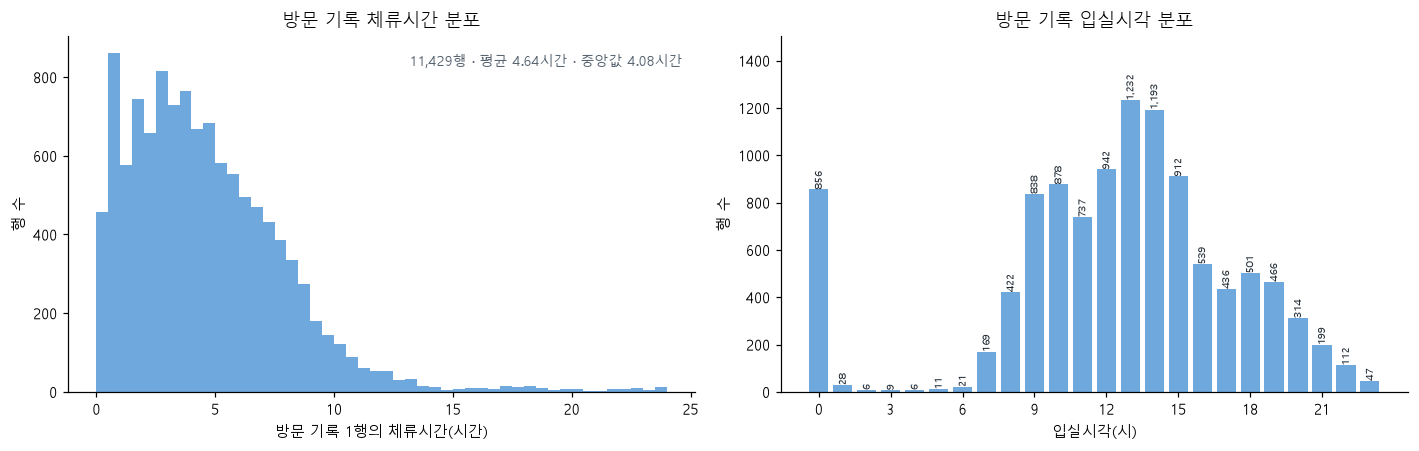

In [5]:
span_seconds = (visit["leave"] - visit["enter"]).dt.total_seconds()
outliers = pd.DataFrame([
    {"점검": "체류초 최솟값(초)", "값": visit["stay_time_second"].min()},
    {"점검": "체류초 최댓값(초)", "값": visit["stay_time_second"].max()},
    {"점검": "체류초 0초 행", "값": int(visit["stay_time_second"].eq(0).sum())},
    {"점검": "체류초 24시간 초과 행", "값": int(visit["stay_time_second"].gt(86400).sum())},
    {"점검": "퇴실이 입실보다 이른 행", "값": int(span_seconds.lt(0).sum())},
    {"점검": "체류초가 입·퇴실 구간보다 긴 행", "값": int((visit["stay_time_second"] > span_seconds).sum())},
    {"점검": "23:59:59 퇴실 행(자정 분할 후보)", "값": int(visit["leave"].dt.strftime("%H:%M:%S").eq("23:59:59").sum())},
]).set_index("점검")
display(outliers)
print("출입 로그 구분값(checkin):", access["checkin"].value_counts().sort_index().to_dict(), "· 1=입실, 2=퇴실(외출 포함)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
stay_hours = visit["stay_time_second"] / 3600
axes[0].hist(stay_hours, bins=48, color=SINGLE_COLOR)
axes[0].set_xlabel("방문 기록 1행의 체류시간(시간)")
axes[0].set_ylabel("행 수")
axes[0].set_title("방문 기록 체류시간 분포")
axes[0].text(0.98, 0.95, f"{len(stay_hours):,}행 · 평균 {stay_hours.mean():.2f}시간 · 중앙값 {stay_hours.median():.2f}시간",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=9, color=MUTED)
enter_hour_raw = visit["enter"].dt.hour.dropna().astype(int)
hour_counts = enter_hour_raw.value_counts().reindex(range(24), fill_value=0)
axes[1].bar(range(24), hour_counts, color=SINGLE_COLOR, width=0.8)
for hour, count in hour_counts.items():            # 시간대별 건수를 작은 글씨로
    axes[1].text(hour, count, f"{count:,}", ha="center", va="bottom", fontsize=6.5, rotation=90, color=INK)
axes[1].set_ylim(0, hour_counts.max() * 1.22)
axes[1].set_xlabel("입실시각(시)")
axes[1].set_ylabel("행 수")
axes[1].set_title("방문 기록 입실시각 분포")
axes[1].set_xticks(range(0, 24, 3))
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

- 체류초는 1초~24시간 안에 있으며 0초나 24시간 초과 같은 명백한 오류는 없다.
- 23:59:59 퇴실 기록은 날짜 경계에서 한 번의 이용이 두 날로 나뉜 흔적이다. 다음 날 00:00:00 입실과 이어지면 새로운 입실이 아니므로 이후 분석에서 구분한다.
- 입실시각은 낮 시간대에 몰려 있지만 00시에 뚜렷한 봉우리가 있다. 이 봉우리는 상당 부분 자정 분할 기록의 영향을 받는다.

### 3.3 고객 흐름

In [6]:
paid = payment.drop_duplicates("user_uuid").set_index("user_uuid")["is_payment"]
assert payment.groupby("user_uuid")["is_payment"].nunique().max() == 1
reg_users = pd.Index(register["user_uuid"].unique())
visit_users = pd.Index(visit["user_uuid"].unique())
access_users = pd.Index(access["user_uuid"].unique())
noshow_users = reg_users.difference(visit_users)

funnel = pd.DataFrame([
    {"단계": "체험 신청 고객", "고객 수": len(reg_users), "결제 고객": int(paid.reindex(reg_users).sum())},
    {"단계": "  방문 고객", "고객 수": len(visit_users), "결제 고객": int(paid.reindex(visit_users).sum())},
    {"단계": "  미방문(노쇼) 고객", "고객 수": len(noshow_users), "결제 고객": int(paid.reindex(noshow_users).sum())},
]).set_index("단계")
funnel["결제율(%)"] = funnel["결제 고객"] / funnel["고객 수"] * 100
display(funnel.round(1))

coverage = pd.DataFrame({"고객 수": {
    "방문 기록 보유": len(visit_users), "출입 로그 보유": len(access_users),
    "둘 다 보유": len(visit_users.intersection(access_users)),
    "방문 기록만": len(visit_users.difference(access_users)),
    "출입 로그만": len(access_users.difference(visit_users))}})
display(coverage)

# 관측 범위: 각 기록이 신청일로부터 며칠째인지 센다(기록일 이전·당일 신청 중 가장 최근 신청일 기준).
trial_base = (register[["user_uuid", "trial_date"]]
              .assign(trial_date=pd.to_datetime(register["trial_date"]))
              .sort_values("trial_date"))


def days_from_trial(stamps, users):
    frame = pd.DataFrame({"user_uuid": np.asarray(users),
                          "기록일": pd.to_datetime(stamps).dt.normalize().to_numpy()})
    frame = frame.dropna().sort_values("기록일")
    merged = pd.merge_asof(frame, trial_base, left_on="기록일", right_on="trial_date", by="user_uuid")
    return (merged["기록일"] - merged["trial_date"]).dt.days


observed = pd.DataFrame({
    "출입 로그 행": days_from_trial(access["logged_at"], access["user_uuid"]).value_counts(),
    "방문 기록 행": days_from_trial(visit["date"], visit["user_uuid"]).value_counts(),
}).fillna(0).astype(int).sort_index()
observed.index.name = "신청일로부터 지난 날짜(일)"
display(observed)

assert (len(reg_users), len(visit_users), len(noshow_users)) == (9624, 6534, 3090)

,고객 수,결제 고객,결제율(%)
단계,,,
체험 신청 고객,9624,3652,37.9000
방문 고객,6534,2564,39.2000
미방문(노쇼) 고객,3090,1088,35.2000


,고객 수
방문 기록 보유,6534
출입 로그 보유,6026
둘 다 보유,6023
방문 기록만,511
출입 로그만,3


,출입 로그 행,방문 기록 행
신청일로부터 지난 날짜(일),,
0,11135,1697
1,29368,4119
2,22846,3322
3,0,2291


- 신청 고객 9,624명 중 3,090명은 `trial_visit_info` 방문 기록이 없다. 이들도 35.2%가 결제했으며, 이 결제는 방문 기록 기반 변수로 설명할 수 없다.
- 방문 고객 6,534명의 결제율은 39.2%다. 본 분석의 핵심 행동 변수(이용일수·평균재실시간·평균입실시각)는 방문 기록에서 만들어지므로 이후 행동 비교와 군집화는 방문 고객에서 출발한다.
- 출입 로그는 신청일부터 신청 2일 뒤까지만 관측되는 반면 방문 기록은 신청 3일 뒤까지 존재한다. 방문 기록만 있는 511명은 모두 신청 3일 뒤 처음 방문해 출입 로그의 상대 관측 구간 밖에 있으므로, 출입 0회로 해석하지 않는다.

In [7]:
# 방문 고객 6,534명의 고객 단위 기본 변수 (정의는 5절에서 자세히 설명)
def to_hour(series):
    return (series.dt.hour + series.dt.minute / 60 + series.dt.second / 3600
            + series.dt.microsecond / 3_600_000_000)


daily = (visit.groupby(["user_uuid", "date"], as_index=False)
         .agg(enter=("enter", "min"), leave=("leave", "max"), stay_seconds=("stay_time_second", "sum"))
         .sort_values(["user_uuid", "date"]).reset_index(drop=True))
daily["valid_time"] = daily["enter"].notna() & daily["leave"].notna()
daily["span_seconds"] = (daily["leave"] - daily["enter"]).dt.total_seconds()
# 일별 재실시간: 해당 날짜의 stay_time_second 합계. 입·퇴실 시각이 유효한 날은 체류초가 구간보다 길면 구간으로 상한을 둔다.
# 고객별로 평균한 값(avg_daily_presence_h)이 평균재실시간이다.
daily["presence_seconds"] = daily["stay_seconds"].astype(float)
capped = daily["valid_time"] & daily["stay_seconds"].gt(daily["span_seconds"])
daily.loc[capped, "presence_seconds"] = daily.loc[capped, "span_seconds"]
# 입실 좌표: 시각이 유효한 날만 사용한다(결측 날은 평균에서 자동 제외).
daily["enter_hour"] = to_hour(daily["enter"])
daily["enter_sin"] = np.sin(2 * np.pi * daily["enter_hour"] / 24)
daily["enter_cos"] = np.cos(2 * np.pi * daily["enter_hour"] / 24)

visitors = daily.groupby("user_uuid").agg(
    usage_day_count=("date", "nunique"),
    avg_daily_presence_h=("presence_seconds", "mean"),
    daily_start_sin=("enter_sin", "mean"),
    daily_start_cos=("enter_cos", "mean"),
    any_valid_time=("valid_time", "any"),
    all_valid_time=("valid_time", "all"),
)
visitors["avg_daily_presence_h"] /= 3600
visitors["daily_start_hour"] = (np.mod(np.arctan2(visitors["daily_start_sin"], visitors["daily_start_cos"]),
                                       2 * np.pi) * 24 / (2 * np.pi))
visitors["is_payment"] = paid.reindex(visitors.index)
visitors["결제 여부"] = np.where(visitors["is_payment"].eq(1), "결제", "미결제")

# 리드타임: 첫 방문일 이전·당일 신청 중 가장 최근 신청일과의 차이(재신청 고객 포함)
register["trial_date"] = pd.to_datetime(register["trial_date"])
first_visit = daily.groupby("user_uuid")["date"].min().rename("first_visit_date").reset_index()
matched = first_visit.merge(register[["user_uuid", "trial_date"]], on="user_uuid", how="left")
matched = matched[matched["trial_date"].le(matched["first_visit_date"])]
matched = matched.sort_values(["user_uuid", "trial_date"]).groupby("user_uuid").tail(1)
visitors["lead_time_days"] = (matched.set_index("user_uuid")["first_visit_date"]
                              - matched.set_index("user_uuid")["trial_date"]).dt.days

assert len(visitors) == 6534 and visitors["is_payment"].notna().all()
assert visitors["lead_time_days"].between(0, 3).all()
print(f"방문 고객 {len(visitors):,}명 · 입·퇴실 시각이 1일 이상 있는 고객 {int(visitors['any_valid_time'].sum()):,}명")

방문 고객 6,534명 · 입·퇴실 시각이 1일 이상 있는 고객 6,207명


**분석 단계별 대상 규모**

분석 단계마다 필요한 변수가 달라 대상 인원도 달라진다. 아래 네 단계를 구분해 사용하며, 각 그래프에는 어떤 단계를 분모로 썼는지 밝힌다. 6,207명과 6,202명의 차이는 중복이나 오류 표본이 아니라 시각 결측을 어디까지 허용하는지에 따른 차이다.

In [8]:
stage_rows = []
for name, index in [("① 체험 신청 고객", reg_users),
                    ("② 방문 기록 보유 고객", visitors.index),
                    ("③ 탐색 대상: 입·퇴실 시각이 하루 이상 유효", visitors.index[visitors["any_valid_time"]]),
                    ("④ 모델링 대상: 모든 이용일의 시각이 유효", visitors.index[visitors["all_valid_time"]])]:
    pay = paid.reindex(index)
    stage_rows.append({"단계": name, "고객 수": len(index), "결제": int(pay.sum()),
                       "미결제": int((pay == 0).sum()), "결제율(%)": pay.mean() * 100})
stages = pd.DataFrame(stage_rows).set_index("단계")
display(stages.round(1))

assert stages["고객 수"].tolist() == [9624, 6534, 6207, 6202]
assert stages["결제"].tolist() == [3652, 2564, 2399, 2394]
assert stages["미결제"].tolist() == [5972, 3970, 3808, 3808]
print("③과 ④의 차이 5명은 일부 이용일의 입·퇴실 시각이 결측인 고객이다. 시각 변수의 대표성이 필요한 모델링에서만 제외한다.")

,고객 수,결제,미결제,결제율(%)
단계,,,,
① 체험 신청 고객,9624,3652,5972,37.9000
② 방문 기록 보유 고객,6534,2564,3970,39.2000
③ 탐색 대상: 입·퇴실 시각이 하루 이상 유효,6207,2399,3808,38.6000
④ 모델링 대상: 모든 이용일의 시각이 유효,6202,2394,3808,38.6000


③과 ④의 차이 5명은 일부 이용일의 입·퇴실 시각이 결측인 고객이다. 시각 변수의 대표성이 필요한 모델링에서만 제외한다.


### 3.4 결제 여부별 행동 비교 (탐색 대상 6,207명)

앞 절의 흐름에서 **입·퇴실 시각이 하루 이상 유효한 6,207명**을 이 절의 탐색 대상으로 삼는다. 시각 변수가 필요한 비교와 그렇지 않은 비교의 분모가 섞이지 않도록, 3.4의 모든 그래프와 표는 이 6,207명을 공통 분모로 쓴다.

**미결제(관측 기간 내 결제 기록 없음)**는 관측 기간 안에 결제 기록이 확인되지 않은 고객을 뜻한다. 이후에는 `미결제`로만 적는다.

| 항목 | 변수 | 정의 |
|---|---|---|
| 결제 여부 | `is_payment` | 결제 기록 유무 |
| 이용일수 | `usage_day_count` | 방문 기록이 있는 서로 다른 달력 날짜의 수 |
| 일평균 이용구간 | `avg_daily_span_h` | 하루 최초 입실부터 마지막 퇴실까지의 구간(외출 포함)을 이용일로 평균한 값 |
| 평균재실시간 | `avg_daily_presence_h` | 일별 체류초 합계를 이용일로 평균한 값(실제로 머문 시간). 최종 모델 입력이다 |
| 자정 보정 입실시각 | 3.4.4에서 계산 | 자정을 넘긴 이용을 한 번으로 이은 뒤, 방문별 첫 입실시각을 원형평균한 시간대 성향 |
| 방문 소요일 | `lead_time_days` | 체험 신청일부터 첫 방문일까지의 날짜 수(0일은 신청 당일) |

In [9]:
# 3.4의 공통 분모: 입·퇴실 시각이 하루 이상 유효한 고객
eda_base = visitors[visitors["any_valid_time"]].copy()
eda_base["avg_daily_span_h"] = daily[daily["valid_time"]].groupby("user_uuid")["span_seconds"].mean() / 3600
assert len(eda_base) == 6207
assert int(eda_base["is_payment"].sum()) == 2399 and int((eda_base["is_payment"] == 0).sum()) == 3808
assert eda_base["avg_daily_span_h"].notna().all()
print(f"3.4 탐색 대상 {len(eda_base):,}명 · 결제 {int(eda_base['is_payment'].sum()):,}명 "
      f"({eda_base['is_payment'].mean() * 100:.1f}%) · 미결제 {int((eda_base['is_payment'] == 0).sum()):,}명 "
      f"({(1 - eda_base['is_payment'].mean()) * 100:.1f}%)")


def style_axis(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e4e7eb", linewidth=0.8)
    ax.set_axisbelow(True)


def paired_bar(ax, table, categories, ylabel, title, label_size=8.5):
    x = np.arange(len(categories))
    width = 0.38
    top = 0.0
    for offset, group in [(-width / 2, "미결제"), (width / 2, "결제")]:
        values = table.reindex(categories)[group].to_numpy(float)
        ax.bar(x + offset, values, width=width - 0.02, color=PAY_COLORS[group], label=group)
        for xi, v in zip(x + offset, values):       # 막대마다 비율을 소수점 첫째 자리로
            ax.text(xi, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=label_size, color=INK)
        top = max(top, float(np.nanmax(values)))
    ax.set_ylim(0, top * 1.16)                      # 라벨이 잘리지 않도록 위쪽 여백
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    style_axis(ax)


def share_with_rate(frame, column, labels=None):
    share = pd.crosstab(frame[column], frame["결제 여부"], normalize="columns") * 100
    rate = frame.groupby(column, observed=True)["is_payment"].agg(["size", "mean"])
    rate.columns = ["고객 수", "결제율(%)"]
    rate["결제율(%)"] *= 100
    table = pd.concat([share[["미결제", "결제"]].add_suffix(" 구성비(%)"), rate], axis=1)
    if labels is not None:
        table.index = labels
        share.index = labels
    return table, share

3.4 탐색 대상 6,207명 · 결제 2,399명 (38.6%) · 미결제 3,808명 (61.4%)


#### 3.4.1 결제·미결제 고객 비율

,고객 수,비율(%)
결제 여부,,
결제,2399,38.6000
미결제,3808,61.4000


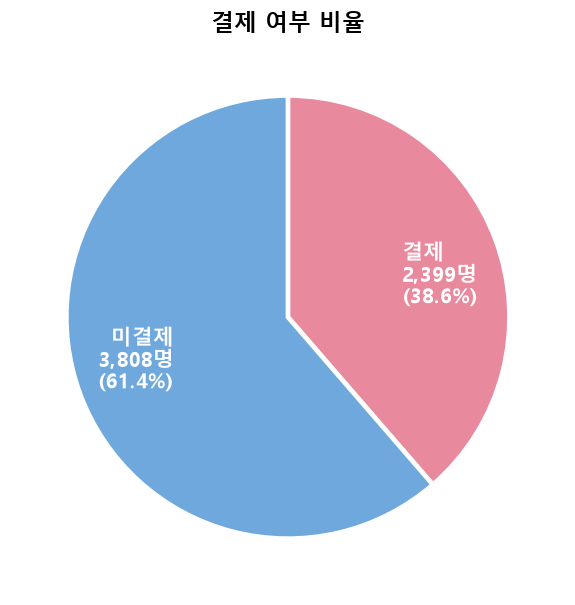

In [10]:
pay_counts = eda_base["결제 여부"].value_counts().reindex(["결제", "미결제"])
pay_table = pd.DataFrame({"고객 수": pay_counts, "비율(%)": pay_counts / len(eda_base) * 100})
display(pay_table.round(1))

assert abs(pay_table["비율(%)"].sum() - 100) < 1e-9
fig, ax = plt.subplots(figsize=(6.4, 5.6))
order = ["결제", "미결제"]
ax.pie([pay_table.loc[g, "고객 수"] for g in order],
       colors=[PAY_COLORS[g] for g in order],
       labels=[f"{g}" + chr(10) + f"{int(pay_table.loc[g, '고객 수']):,}명" + chr(10)
               + f"({pay_table.loc[g, '비율(%)']:.1f}%)" for g in order],
       startangle=90, counterclock=False, labeldistance=0.55,
       textprops={"color": "white", "fontsize": 14, "fontweight": "bold"},
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("결제 여부 비율", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

#### 3.4.2 달력 기준 이용일수

이용일수는 방문 기록이 있는 **서로 다른 달력 날짜의 수**다. 데이터에는 체험 신청일 당일부터 신청 3일 뒤까지 방문 기록이 있어 최대 4개의 달력 날짜가 나타난다. 또한 자정을 넘긴 한 번의 이용이 두 날짜로 나뉠 수 있으므로, 이용일수는 독립된 이용회차와 같지 않다.

,미결제 구성비(%),결제 구성비(%),고객 수,결제율(%)
1일,53.7000,41.8000,3047,32.9000
2일,28.3000,31.6000,1835,41.3000
3일,17.6000,24.1000,1248,46.3000
4일,0.4000,2.6000,77,80.5000


4일 집단 77명 중 자정 분할 기록(23:59:59 퇴실 → 다음 날 00:00:00 입실)이 있는 고객: 26명(33.8%)


→ 자정 분할 기록이 포함될 수 있어, 4일이 네 차례의 독립 방문을 의미하지는 않는다. 인원이 적어 결제율 해석에 유의한다.


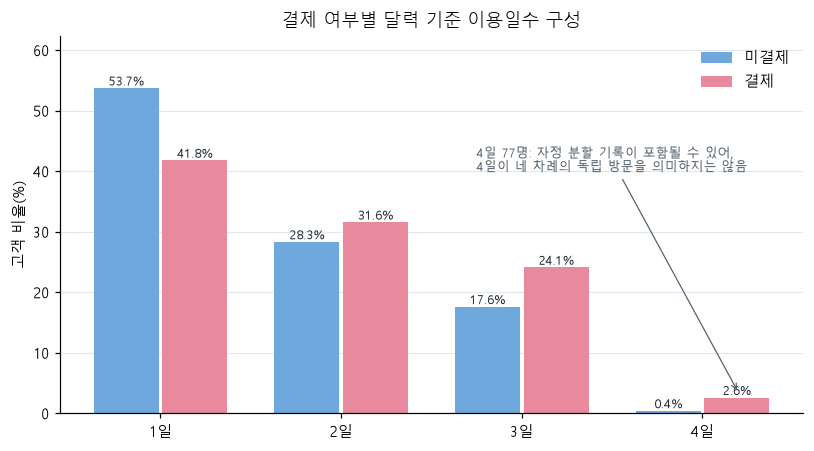

In [11]:
day_table, day_share = share_with_rate(eda_base, "usage_day_count")
day_table.index = [f"{d}일" for d in day_table.index]
day_share.index = [f"{d}일" for d in day_share.index]
display(day_table.round(1))

# 4일 집단의 자정 분할 기록 보유 여부
prev_date_all = daily.groupby("user_uuid")["date"].shift()
prev_leave_all = daily.groupby("user_uuid")["leave"].shift()
daily["exact_midnight_link"] = (
    daily["date"].sub(prev_date_all).dt.days.eq(1)
    & prev_leave_all.eq(prev_date_all + pd.Timedelta(hours=23, minutes=59, seconds=59))
    & daily["enter"].eq(daily["date"]))
eda_base["has_midnight_link"] = daily.groupby("user_uuid")["exact_midnight_link"].any()
four_day = eda_base[eda_base["usage_day_count"].eq(4)]
print(f"4일 집단 {len(four_day):,}명 중 자정 분할 기록(23:59:59 퇴실 → 다음 날 00:00:00 입실)이 있는 고객: "
      f"{int(four_day['has_midnight_link'].sum()):,}명({four_day['has_midnight_link'].mean() * 100:.1f}%)")
print("→ 자정 분할 기록이 포함될 수 있어, 4일이 네 차례의 독립 방문을 의미하지는 않는다. 인원이 적어 결제율 해석에 유의한다.")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
paired_bar(ax, day_share, list(day_share.index), "고객 비율(%)", "결제 여부별 달력 기준 이용일수 구성")
ax.annotate(f"4일 {len(four_day):,}명: 자정 분할 기록이 포함될 수 있어,\n4일이 네 차례의 독립 방문을 의미하지는 않음",
            xy=(3.2, day_share.loc["4일", "결제"] + 0.8), xytext=(1.75, 40),
            fontsize=8.5, color=MUTED, arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

#### 3.4.3 평균재실시간

,평균,중앙값,표준편차,Q1,Q3,고객 수
결제 여부,,,,,,
미결제,4.6500,4.2800,3.0000,2.5100,6.3400,3808
결제,4.0600,3.5900,2.8000,2.0400,5.3700,2399


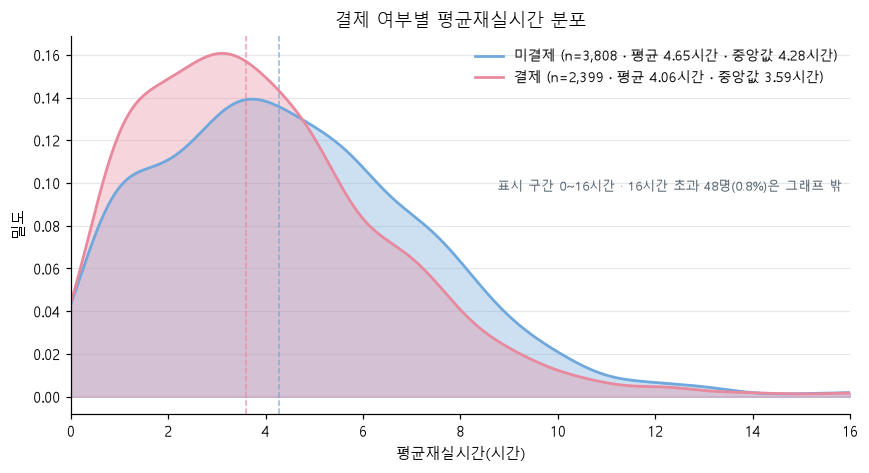

일평균 이용구간(최초 입실~마지막 퇴실, 외출 포함) 기준


,평균,중앙값,표준편차,Q1,Q3,고객 수
결제 여부,,,,,,
미결제,5.6000,4.9100,3.9400,2.7200,7.7800,3808
결제,5.0400,4.2000,3.7800,2.2800,6.8600,2399


In [12]:
def describe_by_payment(frame, column):
    grouped = frame.groupby("결제 여부")[column]
    return pd.DataFrame({"평균": grouped.mean(), "중앙값": grouped.median(), "표준편차": grouped.std(),
                         "Q1": grouped.quantile(0.25), "Q3": grouped.quantile(0.75),
                         "고객 수": grouped.size()}).reindex(["미결제", "결제"])


display(describe_by_payment(eda_base, "avg_daily_presence_h").round(2))

# 밀도 곡선: 가우시안 커널을 직접 계산해 매끄러운 분포를 그린다(변수는 평균재실시간 그대로).
def density_curve(values, grid, bandwidth):
    z = (grid[:, None] - values[None, :]) / bandwidth
    return np.exp(-0.5 * z ** 2).sum(axis=1) / (len(values) * bandwidth * np.sqrt(2 * np.pi))


fig, ax = plt.subplots(figsize=(8, 4.4))
grid = np.linspace(0, 16, 400)
for group in ["미결제", "결제"]:
    values = eda_base.loc[eda_base["결제 여부"].eq(group), "avg_daily_presence_h"].to_numpy(float)
    bandwidth = 1.06 * values.std(ddof=1) * len(values) ** (-1 / 5)     # Silverman 기준
    curve = density_curve(values, grid, bandwidth)
    # 요약값은 표시 구간이 아니라 원자료 전체로 계산한다.
    label = f"{group} (n={len(values):,} · 평균 {values.mean():.2f}시간 · 중앙값 {np.median(values):.2f}시간)"
    ax.plot(grid, curve, color=PAY_COLORS[group], lw=1.8, label=label)
    ax.fill_between(grid, curve, color=PAY_COLORS[group], alpha=0.35)
    ax.axvline(np.median(values), color=PAY_COLORS[group], lw=1, ls="--", alpha=0.8)
ax.set_xlim(0, 16)
beyond = int((eda_base["avg_daily_presence_h"] > 16).sum())
ax.text(0.99, 0.62, f"표시 구간 0~16시간 · 16시간 초과 {beyond}명({beyond / len(eda_base) * 100:.1f}%)은 그래프 밖",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=MUTED)
ax.set_xlabel("평균재실시간(시간)")
ax.set_ylabel("밀도")
ax.set_title("결제 여부별 평균재실시간 분포")
ax.legend(frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()

# 일평균 이용구간: 최초 입실~마지막 퇴실(외출 포함). 평균재실시간과 다른 변수다.
print("일평균 이용구간(최초 입실~마지막 퇴실, 외출 포함) 기준")
display(describe_by_payment(eda_base, "avg_daily_span_h").round(2))

#### 3.4.4 입실 시간대

자정을 넘긴 한 번의 이용은 23:59:59 퇴실과 다음 날 00:00:00 입실로 나뉘어 기록된다. 이를 그대로 쓰면 00시 입실이 실제보다 많아 보이므로, 연속한 두 날짜에서 정확한 자정 연속 기록이거나 앞날 23:30 이후 퇴실·다음 날 00:30 이전 입실이면 한 번의 이용으로 이은 뒤 방문별 첫 입실시각을 원형평균한다. 이 값을 **자정 보정 입실시각**이라 부르며, 최종 모델 입력인 평균입실시각(일 기준)과는 계산 단위가 다르다.

,미결제 구성비(%),결제 구성비(%),"차이(결제-미결제, %p)",고객 수,결제율(%)
입실 3시간 구간,,,,,
00-03,2.0700,1.7500,-0.3200,121,34.7100
03-06,0.6000,0.5000,-0.1000,35,34.2900
06-09,5.1500,3.7100,-1.4400,285,31.2300
09-12,22.1600,20.7600,-1.4100,1342,37.1100
12-15,37.2900,31.7200,-5.5700,2181,34.8900
15-18,20.9000,22.1300,1.2300,1327,40.0200
18-21,8.7200,14.9600,6.2500,691,51.9500
21-24,3.1000,4.4600,1.3600,225,47.5600


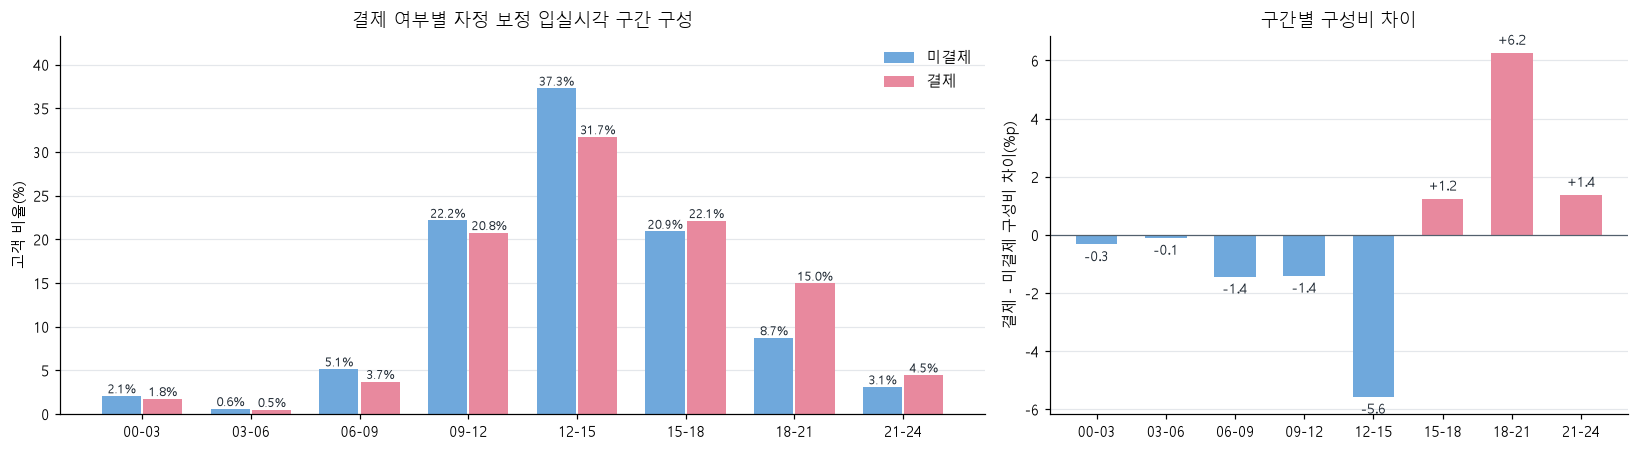

In [13]:
adj_daily = daily[daily["user_uuid"].isin(eda_base.index) & daily["valid_time"]].sort_values(
    ["user_uuid", "date"]).reset_index(drop=True)
adj_prev_date = adj_daily.groupby("user_uuid")["date"].shift()
adj_prev_leave = adj_daily.groupby("user_uuid")["leave"].shift()
adj_consecutive = adj_daily["date"].sub(adj_prev_date).dt.days.eq(1)
adj_exact = (adj_consecutive
             & adj_prev_leave.eq(adj_prev_date + pd.Timedelta(hours=23, minutes=59, seconds=59))
             & adj_daily["enter"].eq(adj_daily["date"]))
adj_near = (adj_consecutive & ~adj_exact
            & (adj_prev_leave.dt.hour * 60 + adj_prev_leave.dt.minute).ge(23 * 60 + 30)
            & (adj_daily["enter"].dt.hour * 60 + adj_daily["enter"].dt.minute).lt(30))
adj_daily["visit_no"] = (~(adj_exact | adj_near)).groupby(adj_daily["user_uuid"]).cumsum()
adj_start = adj_daily.groupby(["user_uuid", "visit_no"])["enter"].first()
adj_angle = 2 * np.pi * to_hour(adj_start) / 24
adj_vector = pd.DataFrame({"sin": np.sin(adj_angle), "cos": np.cos(adj_angle)}).groupby(level="user_uuid").mean()
eda_base["자정 보정 입실시각"] = (np.mod(np.arctan2(adj_vector["sin"], adj_vector["cos"]), 2 * np.pi)
                          * 24 / (2 * np.pi))
assert eda_base["자정 보정 입실시각"].notna().all()

labels_3h = [f"{h:02d}-{h + 3:02d}" for h in range(0, 24, 3)]
eda_base["입실 3시간 구간"] = pd.cut(eda_base["자정 보정 입실시각"], np.arange(0, 25, 3), right=False, labels=labels_3h)
hour_table, hour_share = share_with_rate(eda_base, "입실 3시간 구간")
hour_table.insert(2, "차이(결제-미결제, %p)", hour_table["결제 구성비(%)"] - hour_table["미결제 구성비(%)"])
display(hour_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
paired_bar(axes[0], hour_share, labels_3h, "고객 비율(%)", "결제 여부별 자정 보정 입실시각 구간 구성")
diff = hour_table["차이(결제-미결제, %p)"].reindex(labels_3h)
axes[1].bar(labels_3h, diff, color=[PAY_COLORS["결제"] if v > 0 else PAY_COLORS["미결제"] for v in diff], width=0.6)
axes[1].axhline(0, color=MUTED, linewidth=0.8)
for i, v in enumerate(diff):
    axes[1].text(i, v + (0.2 if v >= 0 else -0.2), f"{v:+.1f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9, color=INK)
axes[1].set_ylabel("결제 - 미결제 구성비 차이(%p)")
axes[1].set_title("구간별 구성비 차이")
style_axis(axes[1])
plt.tight_layout()
plt.show()

#### 3.4.5 방문 소요일(리드타임)

,미결제 구성비(%),결제 구성비(%),고객 수,결제율(%)
0일(신청 당일),25.5000,21.6000,1488,34.8000
1일(다음 날),52.2000,53.0000,3258,39.0000
2일,15.1000,16.4000,969,40.7000
3일,7.2000,9.0000,492,43.9000


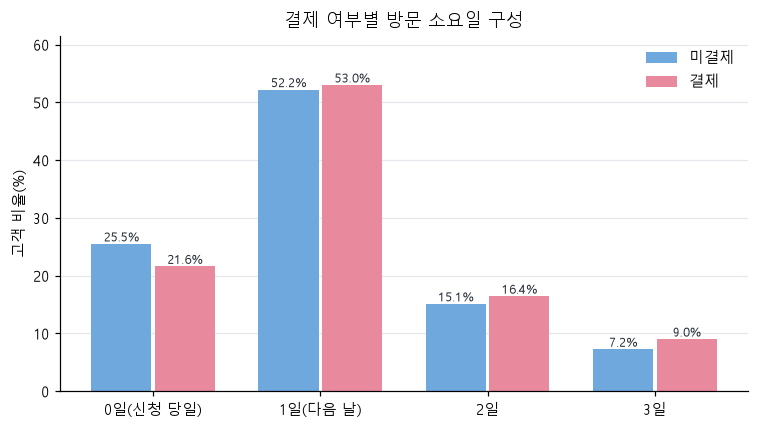

In [14]:
lead_table, lead_share = share_with_rate(eda_base, "lead_time_days")
label_map = {0: "0일(신청 당일)", 1: "1일(다음 날)", 2: "2일", 3: "3일"}
lead_table.index = [label_map[d] for d in lead_table.index]
lead_share.index = [label_map[d] for d in lead_share.index]
display(lead_table.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
paired_bar(ax, lead_share, list(lead_share.index), "고객 비율(%)", "결제 여부별 방문 소요일 구성")
plt.tight_layout()
plt.show()

### 3.5 탐색 결과와 분석 주제

**데이터 품질**

- 네 테이블 모두 완전 중복 행이 있어 제거했다(신청 28행, 방문 48행, 출입 359행, 결제 35행). 고객 식별자 결측은 없다.
- 방문 기록의 입·퇴실 시각 결측 555행은 항상 입실과 퇴실이 함께 비어 있다. 시각 형식이 섞여 있어 혼합 형식으로 변환해야 792행의 유효 시각을 잃지 않는다.
- 체류초는 1초~24시간 범위에 있어 명백한 오류값은 없다.
- 23:59:59 퇴실 기록 728행과 00시 입실 856행(23시 47행, 01시 28행)이 함께 나타난다. 한 번의 이용이 날짜 경계에서 두 기록으로 나뉜 흔적이며, 시간 변수를 설계할 때 이를 구분해야 한다.

**고객 흐름**

- 신청 고객 9,624명 중 방문 고객은 6,534명(결제율 39.2%), 미방문 고객은 3,090명(35.2%)이다. 방문 여부만으로는 결제율 차이가 4.0%p에 그친다.
- 따라서 방문 여부 외에 방문 고객 내부의 이용 행동 차이를 추가로 확인할 필요가 있다.

**탐색 대상 6,207명의 행동 비교**

- **결제 여부 구성:** 미결제 3,808명(61.4%), 결제 2,399명(38.6%)이다.
- **달력 기준 이용일수:** 1일 이용 비중은 미결제 53.7%, 결제 41.8%다. 2일 이상 이용 기록을 가진 비중은 결제 집단에서 상대적으로 높게 관측됐다(2일 31.6% 대 28.3%, 3일 24.1% 대 17.6%). 구간별 관측 결제율은 1일 32.9%, 2일 41.3%, 3일 46.3%다. 4일 집단은 77명으로 80.5%이나 인원이 적다. 이용일수는 달력 날짜 수이고 자정을 넘긴 이용이 두 날짜로 나뉠 수 있어 독립된 방문 횟수와 같지 않으므로, 방문이 늘수록 결제가 늘어난다는 관계로 읽지 않는다.
- **일평균 이용구간(외출 포함):** 결제 집단은 평균 5.04시간·중앙값 4.20시간으로 미결제 집단(5.60시간, 4.91시간)보다 짧게 관측됐다. 실제로 머문 시간인 평균재실시간으로 보아도 방향은 같다(결제 4.06시간·3.59시간, 미결제 4.65시간·4.28시간). 두 집단의 분포가 크게 겹쳐 체류 길이만으로 결제 여부를 설명하기는 어렵다.
- **자정 보정 입실시각:** 두 집단 모두 12–15시가 가장 많지만 이 구간은 미결제 쪽으로 치우친다(미결제 37.3%, 결제 31.7%). 18–21시는 결제 집단에서 6.3%p 높고(미결제 8.7%, 결제 15.0%), 이 구간 고객의 관측 결제율은 52.0%로 가장 높다. 21–24시도 47.6%로 높은 편이다.
- **방문 소요일:** 두 집단 모두 신청 다음 날 방문이 가장 많다(미결제 52.2%, 결제 53.0%). 신청 당일 방문은 미결제 25.5%, 결제 21.6%이고, 구간별 관측 결제율은 당일 34.8%에서 3일 뒤 43.9%로 조금씩 높아진다. 다만 늦게 방문할수록 남은 체험 기간이 짧아지는 구조적 제약이 있어 보조 지표로만 본다.

**분석 주제**

방문 여부와 체류 길이만으로는 관측 결제율 차이를 충분히 설명하기 어려웠고, 달력 기준 이용일수와 이용 시간대에 따라 관측 분포가 달랐다. 이에 **무료체험 방문 고객을 이용일수·평균재실시간·입실 시간대로 군집화해 행동 유형을 도출하고, 유형별 관측 결제율을 사후 비교한다**는 분석 주제를 정한다. 결제 여부는 군집 형성에 사용하지 않으므로 결제를 예측하는 분류 문제가 아니다. 입실 시간대는 순환 변수이고 자정 분할 기록이 섞여 있어, 원형 처리와 자정 연결 구분을 함께 설계한다. 위 결과는 관측된 연관이며 인과관계를 뜻하지 않는다.

## 4. 분석대상 정의

탐색 결과를 바탕으로 모델링 대상을 정한다. 평균입실시각이 핵심 입력이므로, **모든 이용일의 입·퇴실 시각이 관측된 고객**만 모델링 대상으로 둔다.

In [15]:
flow = pd.DataFrame([
    {"단계": "체험 신청 고객", "고객 수": len(reg_users)},
    {"단계": "방문 고객", "고객 수": len(visitors)},
    {"단계": "입·퇴실 시각이 1일 이상 관측된 고객", "고객 수": int(visitors["any_valid_time"].sum())},
    {"단계": "모든 이용일의 입·퇴실 시각이 관측된 고객(모델링 대상)", "고객 수": int(visitors["all_valid_time"].sum())},
]).set_index("단계")
flow["이전 단계 대비 제외"] = (-flow["고객 수"].diff()).fillna(0).astype(int)
display(flow)

cohort_users = visitors.index[visitors["all_valid_time"]]
customers = visitors.loc[cohort_users].copy()
cohort_daily = daily[daily["user_uuid"].isin(cohort_users)].copy()

assert len(customers) == 6202
assert int(customers["is_payment"].sum()) == 2394 and int((customers["is_payment"] == 0).sum()) == 3808
print(f"모델링 대상 {len(customers):,}명 · 결제 {int(customers['is_payment'].sum()):,}명 · "
      f"미결제 {int((customers['is_payment'] == 0).sum()):,}명 · 관측 결제율 {customers['is_payment'].mean() * 100:.1f}%")

,고객 수,이전 단계 대비 제외
단계,,
체험 신청 고객,9624,0
방문 고객,6534,3090
입·퇴실 시각이 1일 이상 관측된 고객,6207,327
모든 이용일의 입·퇴실 시각이 관측된 고객(모델링 대상),6202,5


모델링 대상 6,202명 · 결제 2,394명 · 미결제 3,808명 · 관측 결제율 38.6%


- 방문 기록이 없는 고객 3,090명은 핵심 행동 변수(이용일수·평균재실시간·평균입실시각)를 만들 수 없어 모델링에서 제외한다.
- 방문 고객 가운데 327명은 입·퇴실 시각이 하나도 관측되지 않아 입실시각 변수를 만들 수 없다.
- 남은 6,207명 중 5명은 일부 이용일의 입·퇴실 시각이 결측이다. 이들의 평균입실시각은 관측된 날만 반영하므로 전체 이용일을 대표하지 못한다.
- 따라서 **모든 이용일이 완전 관측된 6,202명**을 모델링 대상으로 사용한다. 결제 고객은 2,394명(38.6%)이다.

## 5. 전처리 및 피처 엔지니어링

### 5.1 모델 입력 변수

| 변수 | 정의 | 변환 |
|---|---|---|
| `usage_day_count` | 체험 기간 중 서로 다른 이용일의 수(1~4일). 평균이 아니라 개수다. | StandardScaler |
| `avg_daily_presence_h` | 일별 `stay_time_second` 합계를 이용일수로 나눈 일평균 재실시간. 체류초가 입·퇴실 구간보다 긴 날은 구간으로 상한을 둔다. 원시 행의 단순 평균이 아니다. | `log1p` 후 RobustScaler |
| `daily_start_sin`, `daily_start_cos` | 일별 최초 입실시각을 `2π × 시각 / 24` 각도로 바꾼 뒤 sin·cos를 고객별로 평균한 원형 좌표 | 고객별 단위벡터화 후 RobustScaler, 각 열에 `1/√2` |

**원형 시간 처리.** 입실시각은 23시와 1시가 두 시간 차이인 순환 변수다. 시각을 그대로 평균하면 23시와 1시의 평균이 12시가 되는 왜곡이 생기므로 sin·cos 좌표로 바꿔 평균한다. 좌표 평균에서 `atan2`로 되돌린 시각이 **평균입실시각**이다. 이름은 평균이지만 시각의 산술평균이 아니라 원형평균이며, 실제 입실 한 건이 아니라 고객별 시간대 성향을 나타낸다.

**`1/√2` 가중.** 입실시각은 하나의 개념이지만 sin·cos 두 열로 들어간다. 두 열에 각각 `1/√2`를 곱해 하나의 개념이 두 변수만큼 거리에 기여하지 않도록 한다. RobustScaler를 쓰므로 분산 합이 정확히 1이 되는 정규화는 아니며, 차원 수를 기준으로 한 공통 감쇠다.

### 5.2 사후 비교 변수 (군집 생성에 사용하지 않음)

| 변수 | 정의 |
|---|---|
| 자정 연결 | 23:59:59 퇴실 뒤 다음 날 00:00:00에 입실한 정확한 연속 기록. 날짜 경계로 분할된 한 번의 이용이다. |
| 이용회차 | 방문 기록 행을 입실 순으로 이어 붙여 한 번의 이용으로 합친 방문 횟수(`episode_count_strict`). 겹치거나 맞닿은 기록, 같은 지점의 정확한 자정 연속 기록, 같은 지점에서 1초 이하 간격으로 나뉜 기록을 잇는다 |
| 이용회차당 재실시간 | 자정 연속 기록을 연결한 뒤 계산한 회차당 평균 재실시간 |
| 주말 이용 비율 | 이용일 중 토·일요일의 비율 |
| 비재실 비율 | 입·퇴실 구간 중 재실로 기록되지 않은 시간의 비율(식사·외출·기록 누락이 섞인 값) |
| 리드타임 | 체험 신청일부터 첫 방문일까지의 날짜 수(0~3일) |
| 관측 결제율 | 군집별 결제 고객 비율 |

In [16]:
# 정확한 자정 연속 기록
cohort_daily = cohort_daily.sort_values(["user_uuid", "date"]).reset_index(drop=True)
prev_date = cohort_daily.groupby("user_uuid")["date"].shift()
prev_leave = cohort_daily.groupby("user_uuid")["leave"].shift()
cohort_daily["exact_midnight_link"] = (
    cohort_daily["date"].sub(prev_date).dt.days.eq(1)
    & prev_leave.eq(prev_date + pd.Timedelta(hours=23, minutes=59, seconds=59))
    & cohort_daily["enter"].eq(cohort_daily["date"])
)
customers["exact_midnight_links"] = cohort_daily.groupby("user_uuid")["exact_midnight_link"].sum()
customers["weekend_usage_ratio"] = (cohort_daily.assign(weekend=cohort_daily["date"].dt.dayofweek.ge(5))
                                    .groupby("user_uuid")["weekend"].mean())

# 비재실 비율: 이용일별 (입·퇴실 구간 - 일별 재실시간)의 합 / 입·퇴실 구간의 합
cohort_daily["outside_seconds"] = (cohort_daily["span_seconds"] - cohort_daily["presence_seconds"]).clip(lower=0)
outside_sum = cohort_daily.groupby("user_uuid")[["outside_seconds", "span_seconds"]].sum()
customers["daily_outside_ratio"] = outside_sum["outside_seconds"] / outside_sum["span_seconds"]
customers["daily_start_vector_strength"] = np.hypot(customers["daily_start_sin"], customers["daily_start_cos"])

In [17]:
# 이용회차(엄격 기준): 방문 기록 행을 고객별 입실 순으로 훑으며 한 번의 이용으로 이을 행을 합친다.
#   - 앞 회차의 퇴실 이전(또는 같은 시각)에 입실한 행: 겹치거나 맞닿은 기록
#   - 같은 지점에서 23:59:59 퇴실 뒤 다음 날 00:00:00에 입실한 행: 정확한 자정 연속 기록
#   - 같은 지점에서 1초 이하 간격으로 이어진 행: 시스템 분할 기록
def build_strict_episodes(rows):
    users = rows["user_uuid"].to_numpy()
    sites = rows["site_id"].to_numpy()
    enters = rows["enter"].to_numpy("datetime64[ns]")
    leaves = rows["leave"].to_numpy("datetime64[ns]")
    enters_sec = enters.astype("datetime64[s]")
    stays = rows["stay_time_second"].to_numpy(dtype=float)
    one_sec, one_day = np.timedelta64(1, "s"), np.timedelta64(1, "D")
    records, cur = [], None          # cur = [고객, 시작, 끝, 재실초 합, 끝 지점]
    for i in range(len(rows)):
        if cur is not None and users[i] == cur[0]:
            end = cur[2]
            gap = (enters[i] - end) / one_sec
            end_sec = end.astype("datetime64[s]")
            end_day = end_sec.astype("datetime64[D]")
            exact = (end_sec - end_day) / one_sec == 86399 and enters_sec[i] == end_day + one_day
            same_site = sites[i] == cur[4]
            if gap <= 0 or (same_site and (exact or gap <= 1.0)):
                if leaves[i] >= end:
                    cur[2], cur[4] = leaves[i], sites[i]
                cur[3] += stays[i]
                continue
            records.append(tuple(cur))
        elif cur is not None:
            records.append(tuple(cur))
        cur = [users[i], enters[i], leaves[i], stays[i], sites[i]]
    if cur is not None:
        records.append(tuple(cur))
    episodes = pd.DataFrame(records, columns=["user_uuid", "start", "end", "presence_seconds", "end_site"])
    episodes["start"] = pd.to_datetime(episodes["start"])
    episodes["end"] = pd.to_datetime(episodes["end"])
    episodes["span_seconds"] = (episodes["end"] - episodes["start"]).dt.total_seconds()
    # 회차 재실시간이 회차 구간보다 길면 구간으로 상한을 둔다.
    episodes["presence_seconds"] = episodes["presence_seconds"].where(
        episodes["presence_seconds"].le(episodes["span_seconds"]), episodes["span_seconds"])
    angle = 2 * np.pi * to_hour(episodes["start"]) / 24
    episodes["start_sin"], episodes["start_cos"] = np.sin(angle), np.cos(angle)
    return episodes


episode_rows = (visit.loc[visit["user_uuid"].isin(customers.index),
                          ["user_uuid", "site_id", "enter", "leave", "stay_time_second"]]
                .sort_values(["user_uuid", "enter", "leave"], kind="mergesort").reset_index(drop=True))
episodes = build_strict_episodes(episode_rows)
episode_agg = episodes.groupby("user_uuid").agg(
    episode_count_strict=("start", "size"), avg_presence_seconds=("presence_seconds", "mean"),
    start_sin=("start_sin", "mean"), start_cos=("start_cos", "mean"))
customers["episode_count_strict"] = episode_agg["episode_count_strict"]
customers["avg_episode_presence_h_strict"] = episode_agg["avg_presence_seconds"] / 3600
customers["episode_start_vector_strength_strict"] = np.hypot(episode_agg["start_sin"], episode_agg["start_cos"])
print(f"방문 기록 {len(episode_rows):,}행 → 이용회차 {len(episodes):,}회 (고객 {episodes['user_uuid'].nunique():,}명)")

방문 기록 10,865행 → 이용회차 10,241회 (고객 6,202명)


In [18]:
# 원본에서 만든 변수의 논리 점검
derived = customers[["usage_day_count", "avg_daily_presence_h", "daily_start_vector_strength",
                     "exact_midnight_links", "episode_count_strict", "avg_episode_presence_h_strict",
                     "episode_start_vector_strength_strict", "daily_outside_ratio",
                     "weekend_usage_ratio", "lead_time_days"]]
assert derived.notna().all().all()
assert customers["episode_count_strict"].ge(1).all()
assert customers["daily_outside_ratio"].between(0, 1).all()
assert customers["weekend_usage_ratio"].between(0, 1).all()
assert customers[["daily_start_vector_strength", "episode_start_vector_strength_strict"]].le(1 + 1e-12).all().all()
assert episodes["presence_seconds"].le(episodes["span_seconds"]).all()
display(derived.describe().T.round(3))
print("원본 4개 테이블에서 만든 입력·사후 변수의 결측·범위 점검을 통과했다.")

,count,mean,std,min,25%,50%,75%,max
usage_day_count,"6,202.0000",1.7340,0.8180,1.0000,1.0000,2.0000,2.0000,4.0000
avg_daily_presence_h,"6,202.0000",4.4230,2.9360,0.0020,2.2640,4.0100,6.0530,23.2960
daily_start_vector_strength,"6,202.0000",0.9140,0.1840,0.0010,0.9370,1.0000,1.0000,1.0000
exact_midnight_links,"6,202.0000",0.0970,0.3410,0.0000,0.0000,0.0000,0.0000,3.0000
episode_count_strict,"6,202.0000",1.6510,0.7840,1.0000,1.0000,1.0000,2.0000,5.0000
avg_episode_presence_h_strict,"6,202.0000",4.8310,3.9830,0.0020,2.3250,4.1320,6.2800,69.2230
episode_start_vector_strength_strict,"6,202.0000",0.9340,0.1560,0.0030,0.9630,1.0000,1.0000,1.0000
daily_outside_ratio,"6,202.0000",0.1160,0.1630,0.0000,0.0090,0.0500,0.1550,0.9450
weekend_usage_ratio,"6,202.0000",0.2230,0.3660,0.0000,0.0000,0.0000,0.5000,1.0000
lead_time_days,"6,202.0000",1.0750,0.8410,0.0000,1.0000,1.0000,1.0000,3.0000


원본 4개 테이블에서 만든 입력·사후 변수의 결측·범위 점검을 통과했다.


In [19]:
def unit_time(frame):
    coords = frame[["daily_start_sin", "daily_start_cos"]].to_numpy(float)
    norm = np.linalg.norm(coords, axis=1, keepdims=True)
    assert (norm > 0).all()
    return coords / norm


def final_input(frame, use_mean_vector=False):
    """최종 모델: 이용일수 Standard · log1p 평균재실시간 Robust · 평균입실시각 단위벡터 Robust × 1/√2"""
    coords = frame[["daily_start_sin", "daily_start_cos"]].to_numpy(float) if use_mean_vector else unit_time(frame)
    return np.hstack([
        StandardScaler().fit_transform(frame[["usage_day_count"]]),
        RobustScaler().fit_transform(np.log1p(frame[["avg_daily_presence_h"]])),
        RobustScaler().fit_transform(coords) * TIME_WEIGHT,
    ])


def candidate1_input(frame):
    """평균재실시간 표준화 K=4: 네 열 모두 StandardScaler, 평균입실시각 단위벡터 × 1/√2"""
    matrix = StandardScaler().fit_transform(np.column_stack([
        frame["usage_day_count"].to_numpy(float),
        np.log1p(frame["avg_daily_presence_h"].to_numpy(float)),
        unit_time(frame)]))
    matrix[:, 2:4] *= TIME_WEIGHT
    return matrix


X_final = final_input(customers)
X_candidate1 = candidate1_input(customers)
print("최종 모델 입력:", X_final.shape, "· 평균재실시간 표준화 K=4 입력:", X_candidate1.shape)

최종 모델 입력: (6202, 4) · 평균재실시간 표준화 K=4 입력: (6202, 4)


## 6. 후보 모델 설계와 비교

세 모델을 **같은 6,202명**에서 같은 평가 절차로 비교한다. 먼저 모델별 입력 설계를 정의하고(6.1), 각 설계에서 군집 수 K를 고른 뒤(6.2), 선정한 K로 세 모델을 비교한다(6.3).

### 6.1 모델별 입력 설계

| 모델 | 목적 | 입력 | 스케일링 | K |
|---|---|---|---|---:|
| 이용구간 표준화 K=4 | 비교 기준 모델. 달력 이용일수·이용구간(외출 포함)·자정 보정 입실시각 | `visit_days`, `log1p(avg_daily_stay)`, `midnight_adjusted_enter_sin/cos` | 네 열 StandardScaler | 4 |
| 평균재실시간 표준화 K=4 | 체류시간 변수를 평균재실시간으로 바꾸고 입실시각을 단위벡터 + 1/√2로 정규화 | 이용일수, `log1p(평균재실시간)`, 평균입실시각 sin/cos | 네 열 StandardScaler, sin/cos × `1/√2` | 4 |
| 평균재실시간 혼합 스케일 K=5 (최종) | 같은 입력에 이상치에 강한 스케일링을 섞어 적용 | 이용일수, `log1p(평균재실시간)`, 평균입실시각 sin/cos | **혼합 스케일:** 이용일수 StandardScaler, 평균재실시간·입실시각 RobustScaler, sin/cos × `1/√2` | 5 |

**평가 지표**

주 지표로 모델을 고르고, 추가 보조 검증으로 같은 결론이 유지되는지 확인한다.

- **주 지표**
  - silhouette: 군집 안은 가깝고 군집 사이는 먼 정도(−1~1, 높을수록 좋음)
  - 최소 군집 비중: 가장 작은 군집이 해석·활용 가능한 크기인지
  - 해석 가능성: 군집이 이용 행동으로 설명되는지(7절, 7.1절)
- **추가 보조 검증**
  - Davies-Bouldin(DBI): 군집 내 퍼짐 대비 군집 간 거리(낮을수록 좋음)
  - Calinski-Harabasz(CH): 군집 간 분산 대비 군집 내 분산의 비(높을수록 좋음)
  - bootstrap ARI: 고객을 복원추출해 20회(시드 20260917) 다시 적합한 뒤 전체 고객을 예측하고, 원래 군집과 얼마나 같은지(0~1) 평균·최저값으로 본다

**이용구간 표준화 K=4의 입력 정의**

- `visit_days`: 달력 기준 이용일수(최종 모델의 이용일수와 같다)
- `avg_daily_stay`: 이용일별 최초 입실부터 마지막 퇴실까지의 구간(외출 포함)을 평균한 시간
- `midnight_adjusted_enter_sin/cos`: 자정을 넘긴 이용을 한 방문으로 이은 뒤, 방문별 첫 입실시각의 sin·cos를 고객별로 평균한 값. 연속한 두 날짜에서 앞날 퇴실과 다음 날 입실이 정확한 자정 연속 기록이거나, 앞날 23:30 이후 퇴실·다음 날 00:30 이전 입실이면 한 방문으로 본다

In [20]:
def bootstrap_ari(X, k, labels):
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    scores = []
    for draw in range(BOOTSTRAP_DRAWS):
        idx = rng.integers(0, len(X), len(X))
        fitted = KMeans(k, n_init=N_INIT, random_state=1000 + draw).fit(X[idx])
        scores.append(adjusted_rand_score(labels, fitted.predict(X)))
    return float(np.mean(scores)), float(np.min(scores))


def evaluate(name, X, k):
    labels = KMeans(k, n_init=N_INIT, random_state=SEED).fit_predict(X)
    boot_mean, boot_min = bootstrap_ari(X, k, labels)
    return {"모델": name, "K": k, "표본": len(X),
            "silhouette": silhouette_score(X, labels), "DBI": davies_bouldin_score(X, labels),
            "CH": calinski_harabasz_score(X, labels),
            "bootstrap ARI 평균": boot_mean, "bootstrap ARI 최저": boot_min,
            "최소 군집 비중(%)": np.bincount(labels).min() / len(labels) * 100}, labels


# 이용구간 표준화 K=4 입력: 자정 전후 30분 이내로 이어진 이용일을 한 방문으로 묶는다.
variant_daily = cohort_daily.sort_values(["user_uuid", "date"]).reset_index(drop=True)
v_prev_date = variant_daily.groupby("user_uuid")["date"].shift()
v_prev_leave = variant_daily.groupby("user_uuid")["leave"].shift()
v_consecutive = variant_daily["date"].sub(v_prev_date).dt.days.eq(1)
v_exact = (v_consecutive & v_prev_leave.eq(v_prev_date + pd.Timedelta(hours=23, minutes=59, seconds=59))
           & variant_daily["enter"].eq(variant_daily["date"]))
v_near = (v_consecutive & ~v_exact
          & (v_prev_leave.dt.hour * 60 + v_prev_leave.dt.minute).ge(23 * 60 + 30)
          & (variant_daily["enter"].dt.hour * 60 + variant_daily["enter"].dt.minute).lt(30))
variant_daily["adjusted_visit_no"] = (~(v_exact | v_near)).groupby(variant_daily["user_uuid"]).cumsum()
adjusted_start = variant_daily.groupby(["user_uuid", "adjusted_visit_no"])["enter"].first()
adjusted_angle = 2 * np.pi * to_hour(adjusted_start) / 24
variant_frame = pd.DataFrame({
    "visit_days": variant_daily.groupby("user_uuid")["date"].size(),
    "avg_daily_stay": variant_daily.groupby("user_uuid")["span_seconds"].mean() / 3600,
    "midnight_adjusted_enter_sin": np.sin(adjusted_angle).groupby(level="user_uuid").mean(),
    "midnight_adjusted_enter_cos": np.cos(adjusted_angle).groupby(level="user_uuid").mean(),
}).loc[customers.index]
assert variant_frame["visit_days"].eq(customers["usage_day_count"]).all()
assert (variant_frame["avg_daily_stay"] >= customers["avg_daily_presence_h"] - 1e-9).all()
variant_frame["avg_daily_stay"] = np.log1p(variant_frame["avg_daily_stay"])
X_variant = StandardScaler().fit_transform(variant_frame)

MODEL_INPUTS = {"이용구간 표준화": X_variant, "평균재실시간 표준화": X_candidate1, "평균재실시간 혼합 스케일": X_final}
print("모델별 입력 행렬:", {name: X.shape for name, X in MODEL_INPUTS.items()})

모델별 입력 행렬: {'이용구간 표준화': (6202, 4), '평균재실시간 표준화': (6202, 4), '평균재실시간 혼합 스케일': (6202, 4)}


### 6.2 군집 수(K) 선정

세 설계 각각에서 K=2~7을 적합해 주 지표를 비교한다. 두 유형으로 나누는 K=2도 가능한 후보이므로 탐색에 포함한다.

**사용하는 지표**

- silhouette: 군집 안은 가깝고 군집 사이는 먼 정도(높을수록 좋음)
- 관성(inertia)과 그 감소율: 군집 중심까지 거리 제곱합. K를 하나 늘렸을 때 감소율이 꺾이는 지점을 Elbow로 본다. 감소율은 직전 K와 비교한 값이므로 K=3부터 계산된다.
- DBI: 군집 내 퍼짐 대비 군집 간 거리(낮을수록 좋음). 참고 보조 지표로만 함께 싣고 K 선택 근거로 쓰지 않는다.
- 최소 군집 비중: 가장 작은 군집의 비중과 인원. 정해진 기준선을 두지 않고, 그 군집을 실제로 설명하고 활용할 수 있는 규모인지 인원과 함께 확인했다.

K는 위 지표와 함께 **유형별 제안을 도출한다는 분석 목적에 맞는 해석 가능성과 간결성**을 고려해 정했다. 지표 하나로 기계적으로 결정되는 값이 아니므로, 모델별 선택 근거를 아래에 밝힌다. 선정한 K가 재표본에서도 유지되는지는 6.3의 bootstrap ARI로 사후에 확인하며, 이 값은 K 후보를 거르는 데 사용하지 않는다.

In [21]:
K_RANGE = range(2, 8)

scan_rows = []
for name, X in MODEL_INPUTS.items():
    for k in K_RANGE:
        km = KMeans(k, n_init=N_INIT, random_state=SEED).fit(X)
        k_labels = km.labels_
        scan_rows.append({"모델": name, "K": k,
                          "silhouette": silhouette_score(X, k_labels),
                          "관성": km.inertia_,
                          "DBI(참고)": davies_bouldin_score(X, k_labels),
                          "최소 군집 비중(%)": np.bincount(k_labels).min() / len(k_labels) * 100})
k_scan = pd.DataFrame(scan_rows)
# 관성 감소율: K를 하나 늘렸을 때 관성이 줄어든 비율. 값이 꺾이는 지점이 Elbow다.
k_scan["관성 감소율(%)"] = k_scan.groupby("모델")["관성"].transform(lambda x: -x.pct_change() * 100)

SELECTED_K = {"이용구간 표준화": 4, "평균재실시간 표준화": 4, "평균재실시간 혼합 스케일": 5}
k_scan["선정"] = np.where(k_scan["K"].eq(k_scan["모델"].map(SELECTED_K)), "선정", "")
display(k_scan.set_index(["모델", "K"]).round(4))
assert set(SELECTED_K) == set(MODEL_INPUTS)
assert all(k in list(K_RANGE) for k in SELECTED_K.values())

silhouette          관성  DBI(참고)  최소 군집 비중(%)  관성 감소율(%)  선정
모델            K                                                             
이용구간 표준화      2      0.2719 17,725.2647   1.4636      44.2115        NaN    
              3      0.2688 13,943.0100   1.2967      28.1038    21.3382    
              4      0.2750 11,349.1960   1.1737      19.0261    18.6030  선정
              5      0.2882  9,847.5370   1.0949       4.4985    13.2314    
              6      0.2954  8,653.0731   1.1050       4.5308    12.1296    
              7      0.2922  7,700.9623   1.0953       4.2406    11.0032    
평균재실시간 표준화    2      0.2672 13,188.9686   1.4523      45.9368        NaN    
              3      0.2840  9,881.6540   1.2331      27.5395    25.0764    
              4      0.2919  8,359.9443   1.2445      16.5269    15.3993  선정
              5      0.2760  7,356.8613   1.2410      12.8668    11.9987    
              6      0.2861  6,564.2577   1.1362      12.2057    10.7737    
              7      0.2966  5,836.8149   1.1375      10.8030    11.0819    
평균재실시간 혼합 스케일 2      0.3573  8,165.1414   1.1818      49.1777        NaN    
              3      0.3090  6,445.9801   1.2596      21.2996    21.0549    
              4      0.3196  5,245.9843   1.2506      21.2996    18.6162    
              5      0.3528  4,350.7174   1.0582      11.9639    17.0658  선정
              6      0.3443  3,877.5681   1.0978      11.0448    10.8752    
              7      0.3653  3,462.8164   1.0618       3.9503    10.6962

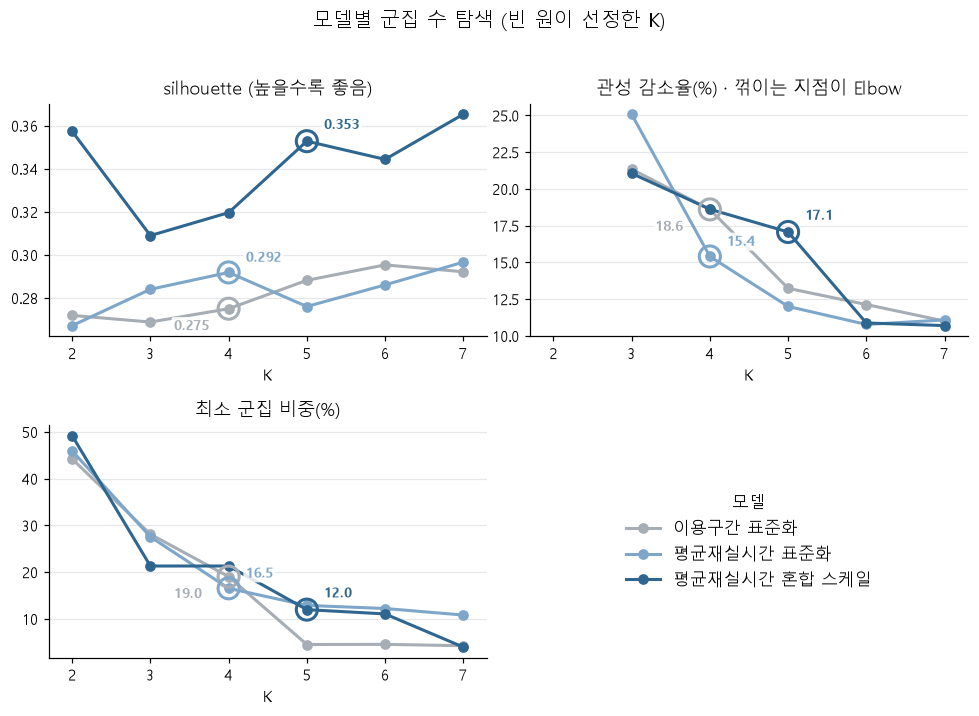

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6.6))
flat = axes.ravel()
LABEL_OFFSETS = {"이용구간 표준화": (-36, -14), "평균재실시간 표준화": (11, 7), "평균재실시간 혼합 스케일": (11, 8)}
panels = [("silhouette", "silhouette (높을수록 좋음)"),
          ("관성 감소율(%)", "관성 감소율(%) · 꺾이는 지점이 Elbow"),
          ("최소 군집 비중(%)", "최소 군집 비중(%)")]
for ax, (column, title) in zip(flat, panels):
    for name, group in k_scan.groupby("모델", sort=False):
        ax.plot(group["K"], group[column], marker="o", lw=2, color=MODEL_COLORS[name], label=name)
        picked = group[group["K"].eq(SELECTED_K[name])]
        ax.scatter(picked["K"], picked[column], s=190, facecolor="none", edgecolor=MODEL_COLORS[name], lw=2, zorder=5)
        for kx, value in zip(picked["K"], picked[column]):      # 채택한 K의 지표값만 표기
            fmt = f"{value:.3f}" if column == "silhouette" else f"{value:.1f}"
            ax.annotate(fmt, (kx, value), textcoords="offset points", xytext=LABEL_OFFSETS[name],
                        fontsize=9, color=MODEL_COLORS[name], fontweight="bold", zorder=6,
                        bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("K")
    ax.set_xticks(list(K_RANGE))
    ax.set_xlim(1.7, 7.3)
    ax.grid(axis="y", color="#e5e7eb")
    ax.spines[["top", "right"]].set_visible(False)
flat[3].axis("off")
handles, texts = flat[0].get_legend_handles_labels()
flat[3].legend(handles, texts, loc="center", frameon=False, fontsize=11, title="모델", title_fontsize=11)
fig.suptitle("모델별 군집 수 탐색 (빈 원이 선정한 K)", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [23]:
# 최종 모델 입력을 K=2로 나눴을 때의 프로파일. K=5를 고른 이유를 수치로 확인한다.
k2_labels = KMeans(2, n_init=N_INIT, random_state=SEED).fit_predict(X_final)
k2_profile = pd.DataFrame({
    "인원": customers.groupby(k2_labels).size(),
    "비중(%)": customers.groupby(k2_labels).size() / len(customers) * 100,
    "이용일수 평균": customers.groupby(k2_labels)["usage_day_count"].mean(),
    "평균재실시간 평균(시간)": customers.groupby(k2_labels)["avg_daily_presence_h"].mean(),
    "평균입실시각(시)": [float(np.mod(np.arctan2(*unit_time(customers[k2_labels == c]).mean(axis=0)),
                                 2 * np.pi) * 24 / (2 * np.pi)) for c in range(2)],
})
k2_profile.index = [f"K=2 군집 {c}" for c in k2_profile.index]
display(k2_profile.round(2))
print("K=2는 1일 이용군과 반복 이용군을 구분하지만 두 군집의 평균입실시각 차이는 "
      f"{abs(k2_profile['평균입실시각(시)'].diff().iloc[-1]):.2f}시간에 그친다.")

,인원,비중(%),이용일수 평균,평균재실시간 평균(시간),평균입실시각(시)
K=2 군집 0,3152,50.8200,2.4400,4.9200,14.3000
K=2 군집 1,3050,49.1800,1.0000,3.9100,14.0400


K=2는 1일 이용군과 반복 이용군을 구분하지만 두 군집의 평균입실시각 차이는 0.27시간에 그친다.


**모델별 K 선택 근거**

- **이용구간 표준화 K=4:** 관성 감소율이 K=4까지 18.6%를 유지하다가 K=5에서 13.2%로 꺾인다. silhouette은 K=6이 0.295로 가장 높지만 이때 최소 군집이 4.5%(281명)까지 줄어 군집 하나를 따로 설명하기 어려워진다. 초기 기준 모델이므로 Elbow 지점인 K=4를 사용한다.
- **평균재실시간 표준화 K=4:** 관성 감소율이 K=4 이후 완만해졌다. silhouette은 K=4가 0.2919이고 K=7이 0.2966으로 차이가 0.0047에 불과하며, K=5(0.2760)와 K=6(0.2861)에서는 오히려 낮아져 K 증가에 따른 일관된 개선으로 보기 어렵다. 따라서 군집 분리도와 해석 간결성을 함께 고려해 K=4를 선택하였다.
- **평균재실시간 혼합 스케일 K=5:** 관성 감소율이 K=5까지 17.1%를 유지하다가 K=6에서 10.9%로 꺾인다. silhouette은 K=5가 0.353으로 K=3·4·6보다 높다. K=2는 silhouette이 0.357로 가장 높지만, 위 표처럼 1일 이용군과 반복 이용군이라는 두 큰 집단으로만 갈리고 평균입실시각은 두 군집이 거의 같다. 1일 이용 안의 단시간과 장시간, 반복 강도의 차이, 저녁 시간대 이용을 각각의 유형으로 나누지 못해 유형별 제안이라는 목적에는 지나치게 단순하다. K=5의 최소 군집은 11.96%(742명)로 유형별 제안을 세울 만한 규모다. K=7은 silhouette이 0.365로 더 높으나 최소 군집이 3.95%(245명)로 작고 군집 수가 늘어 해석이 복잡해진다. 참고 보조 지표인 DBI도 K=5에서 1.058로 가장 낮았다.

K=2~7 가운데 어느 값도 모든 지표에서 동시에 가장 좋지는 않았다. 위 선택은 지표와 해석 가능성을 함께 고려한 판단이며, 선택한 K에서 군집이 재표본에도 유지되는지는 6.3에서 확인한다.

### 6.3 모델 비교 결과

각 설계에서 선정한 K로 같은 6,202명에 적합한 결과다.

In [24]:
rows, model_labels = [], {}
for name, X, k in [("이용구간 표준화 K=4", X_variant, SELECTED_K["이용구간 표준화"]),
                   ("평균재실시간 표준화 K=4", X_candidate1, SELECTED_K["평균재실시간 표준화"]),
                   ("평균재실시간 혼합 스케일 K=5 (최종)", X_final, SELECTED_K["평균재실시간 혼합 스케일"])]:
    row, labels = evaluate(name, X, k)
    rows.append(row)
    model_labels[name] = labels
comparison = pd.DataFrame(rows).set_index("모델")
display(comparison.round(4))

,K,표본,silhouette,DBI,CH,bootstrap ARI 평균,bootstrap ARI 최저,최소 군집 비중(%)
모델,,,,,,,,
이용구간 표준화 K=4,4,6202,0.2750,1.1737,"2,450.0343",0.9518,0.9214,19.0261
평균재실시간 표준화 K=4,4,6202,0.2919,1.2445,"2,532.1215",0.9799,0.9376,16.5269
평균재실시간 혼합 스케일 K=5 (최종),5,6202,0.3528,1.0582,"3,145.7047",0.9797,0.9551,11.9639


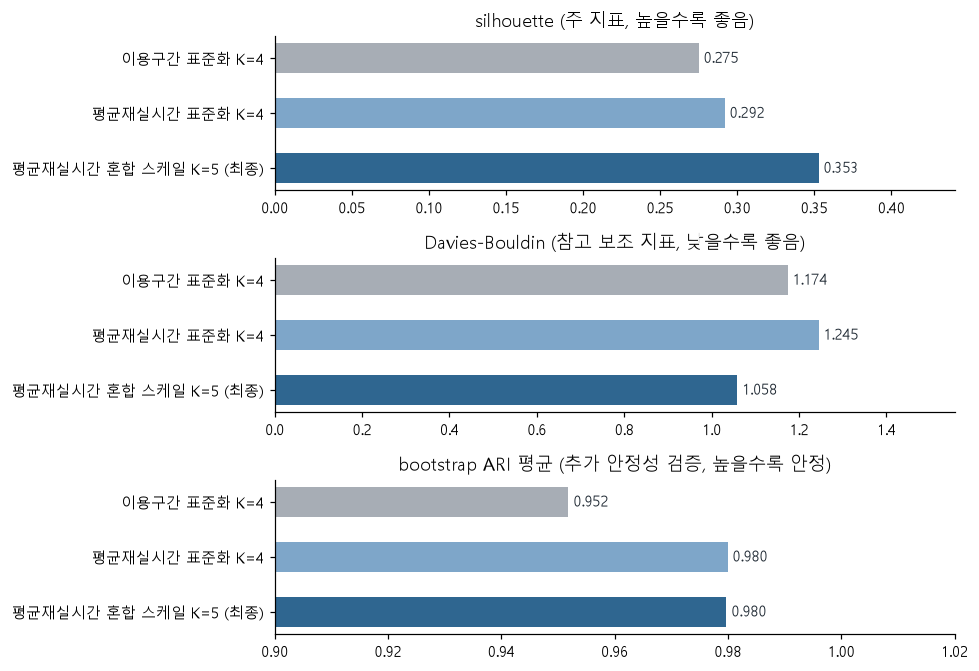

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(9, 6.2))
order = comparison.index.tolist()
# 표시 모델명에서 K 표기를 뗀 이름으로 K 탐색 그래프와 같은 색을 찾는다.
colors = [MODEL_COLORS[name.split(" K=")[0]] for name in order]
for ax, metric, title in [(axes[0], "silhouette", "silhouette (주 지표, 높을수록 좋음)"),
                          (axes[1], "DBI", "Davies-Bouldin (참고 보조 지표, 낮을수록 좋음)"),
                          (axes[2], "bootstrap ARI 평균", "bootstrap ARI 평균 (추가 안정성 검증, 높을수록 안정)")]:
    values = comparison[metric]
    ax.barh(order, values, color=colors, height=0.55)
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:.3f}", va="center", fontsize=10, color=INK)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(0, values.max() * 1.25)
axes[2].set_xlim(0.9, 1.02)
plt.tight_layout()
plt.show()

## 7. 최종 모델 선정

**평균재실시간 혼합 스케일 K=5를 최종 모델로 선정한다.**

- **분리도(주 지표):** silhouette 0.353은 비교한 세 모델 중 가장 높았다. 평균재실시간 표준화 K=4는 0.292였다. 최소 군집은 11.96%(742명)다.
- **군집 수:** K는 6.2에서 silhouette, 관성 감소율(Elbow), 군집 규모와 해석 가능성을 함께 보고 K=5로 정했다. K=2는 silhouette이 조금 더 높지만 1일 이용군과 반복 이용군 두 집단으로만 갈려 시간대와 이용 강도의 차이를 유형으로 나누지 못하고, K=7은 최소 군집이 3.95%(245명)로 작다.
- **해석:** 평균재실시간 표준화 K=4에서 하나였던 여러 날 이용 고객이 달력 기준 2일 이용형과 평균 3.06일의 고반복형으로 나뉜다. 사후 이용회차도 각각 2.00회와 2.99회로 차이가 난다.
- **추가 보조 검증:** DBI 1.058로 세 모델 중 가장 낮았고(평균재실시간 표준화 K=4는 1.245), bootstrap ARI 평균 0.980·최저 0.955로 평균재실시간 표준화 K=4와 평균이 같고 최저값은 더 높았다. 보조 지표도 같은 결론을 지지한다.
- 이용구간 표준화 K=4는 입실시각을 sin·cos 두 개의 표준화 열로 사용해 시간 개념이 거리 계산에 상대적으로 크게 반영될 가능성이 있다. 나머지 두 모델은 sin·cos에 각각 `1/√2`를 적용해 이 차원 수 효과를 완화했다.

**최종 파이프라인**

1. 분석대상: 모든 이용일의 입·퇴실 시각이 관측된 6,202명
2. 입력: `usage_day_count`, `log1p(avg_daily_presence_h)`, 고객별 평균입실시각의 `daily_start_sin`, `daily_start_cos`
3. 스케일링: 이용일수 StandardScaler, 평균재실시간 RobustScaler, sin·cos는 고객별 단위벡터화 후 RobustScaler와 각 `1/√2`
4. 군집화: `KMeans(n_clusters=5, random_state=42, n_init=10)`
5. 결제 여부는 군집 생성과 K 선택에 사용하지 않는다.

In [26]:
final_model = KMeans(K_FINAL, n_init=N_INIT, random_state=SEED).fit(X_final)
labels = final_model.labels_
assert np.array_equal(labels, model_labels["평균재실시간 혼합 스케일 K=5 (최종)"])
assert sorted(np.bincount(labels).tolist(), reverse=True) == [1718, 1413, 1373, 956, 742]
assert np.bincount(labels).sum() == 6202

# 군집명: 평균입실시각이 가장 늦은 군집 → 저녁심야형, 평균재실시간 중앙값이 가장 짧은 군집 → 단시간체험형,
# 나머지는 이용일수 평균이 적은 순서로 풀타임체험형 · 재방문탐색형 · 주간반복형
def circular_mean_hour(frame):
    coords = unit_time(frame)
    return float(np.mod(np.arctan2(coords[:, 0].mean(), coords[:, 1].mean()), 2 * np.pi) * 24 / (2 * np.pi))


base = pd.DataFrame({
    "평균입실시각": {c: circular_mean_hour(customers[labels == c]) for c in range(K_FINAL)},
    "평균재실시간 중앙값": customers.groupby(labels)["avg_daily_presence_h"].median(),
    "이용일수 평균": customers.groupby(labels)["usage_day_count"].mean(),
})
evening = int(base["평균입실시각"].idxmax())
short = int(base.drop(index=evening)["평균재실시간 중앙값"].idxmin())
rest = base.drop(index=[evening, short]).sort_values("이용일수 평균").index.tolist()
CLUSTER_NAMES = {evening: "저녁심야형", short: "단시간체험형",
                 rest[0]: "풀타임체험형", rest[1]: "재방문탐색형", rest[2]: "주간반복형"}
NAME_ORDER = ["풀타임체험형", "단시간체험형", "재방문탐색형", "주간반복형", "저녁심야형"]
customers["군집"] = pd.Categorical([CLUSTER_NAMES[c] for c in labels], categories=NAME_ORDER, ordered=True)

expected_sizes = {"저녁심야형": 742, "주간반복형": 956, "재방문탐색형": 1373, "단시간체험형": 1413, "풀타임체험형": 1718}
assert customers["군집"].value_counts().to_dict() == expected_sizes
print("최종 군집 인원:", customers["군집"].value_counts().reindex(NAME_ORDER).to_dict())

최종 군집 인원: {'풀타임체험형': 1718, '단시간체험형': 1413, '재방문탐색형': 1373, '주간반복형': 956, '저녁심야형': 742}


### 7.1 세 모델의 군집 구조 비교 (산점도)

세 모델을 같은 형식의 그림으로 비교한다. 모델마다 한 줄에 세 개의 그림을 둔다.

- **원변수 산점도 2개:** 표시용 원래 단위(이용일수, 시간, 입실시각)로 그린다. 이용일수는 1~4의 정수라 점이 겹치므로 그림에서만 작은 흔들림(균등분포 ±0.18, 시드 42)을 더한다. 시간 축은 긴 꼬리가 있어 로그축으로 표시한다. 이용구간 표준화 K=4의 시간은 평균재실시간이 아니라 외출을 포함한 일평균 이용구간이고, 입실시각은 자정 보정 입실시각이다.
- **PCA 산점도:** 각 모델이 실제 군집화에 사용한 스케일링 완료 입력 행렬을 2차원으로 투영한다. 큰 X는 군집별 PCA 평균 좌표다. PCA는 모델마다 따로 적합하므로 좌표나 거리를 모델 간에 직접 비교하지 않는다.
- 표본은 추출하지 않고 6,202명을 모두 그린다. 결제 여부는 입력과 색상에 사용하지 않는다.
- 비교 모델의 군집은 인원이 많은 순서로 `군집 1~4`로 표시하고, 범례에 인원·평균 이용일수·시간 중앙값·군집 평균입실시각을 함께 적는다.

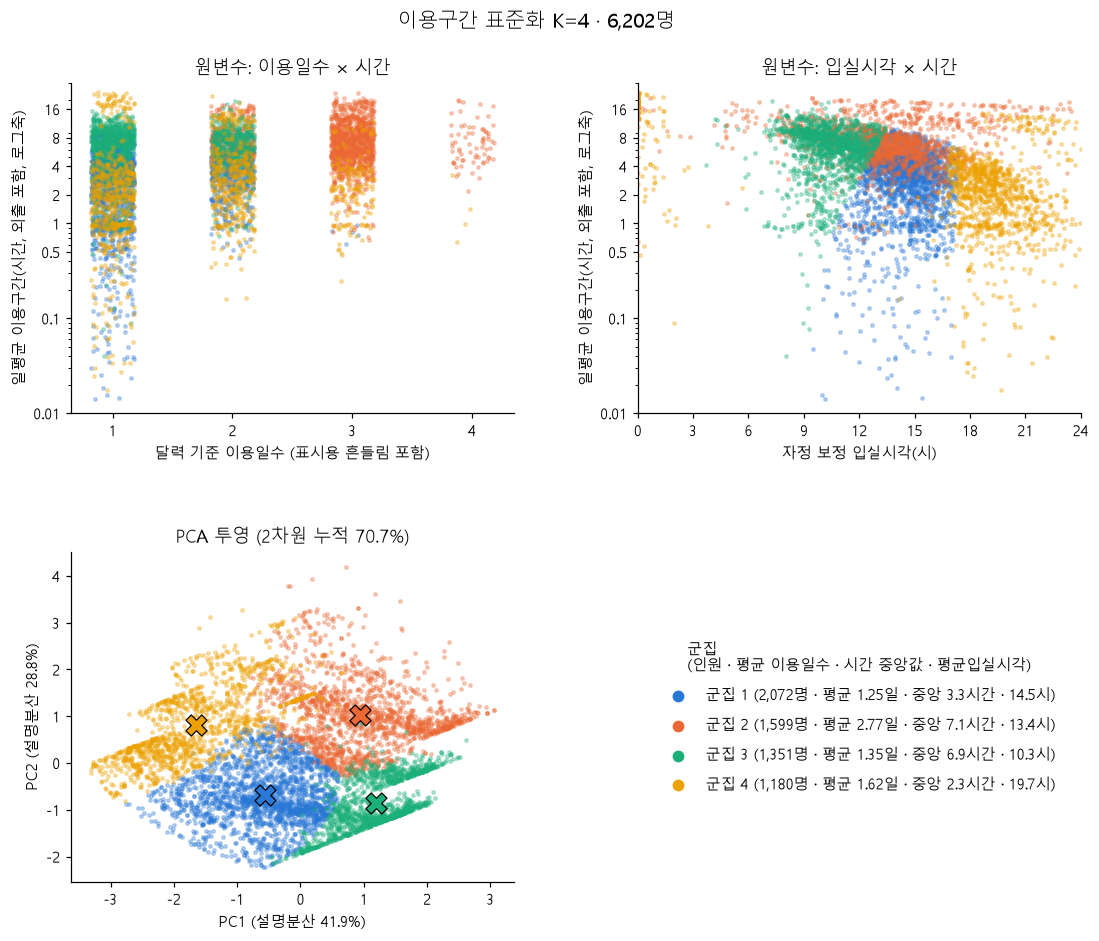

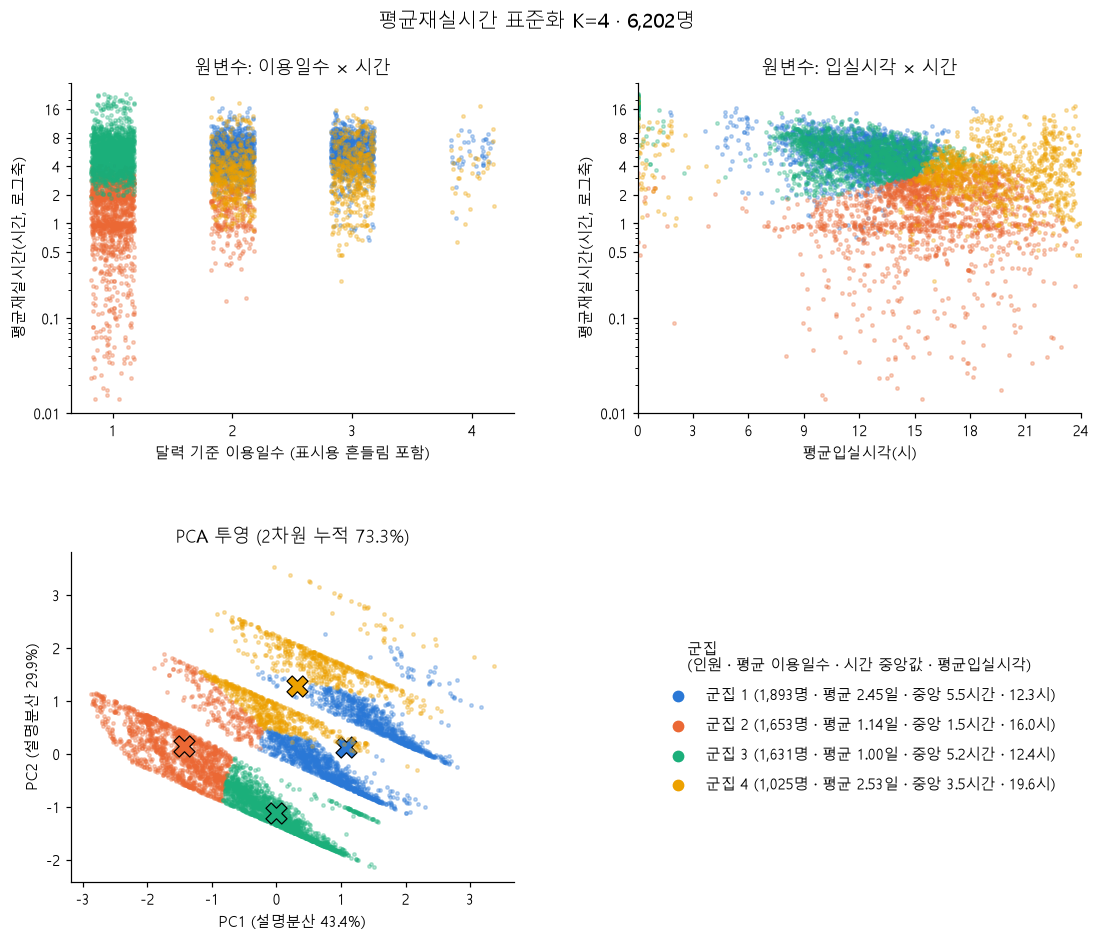

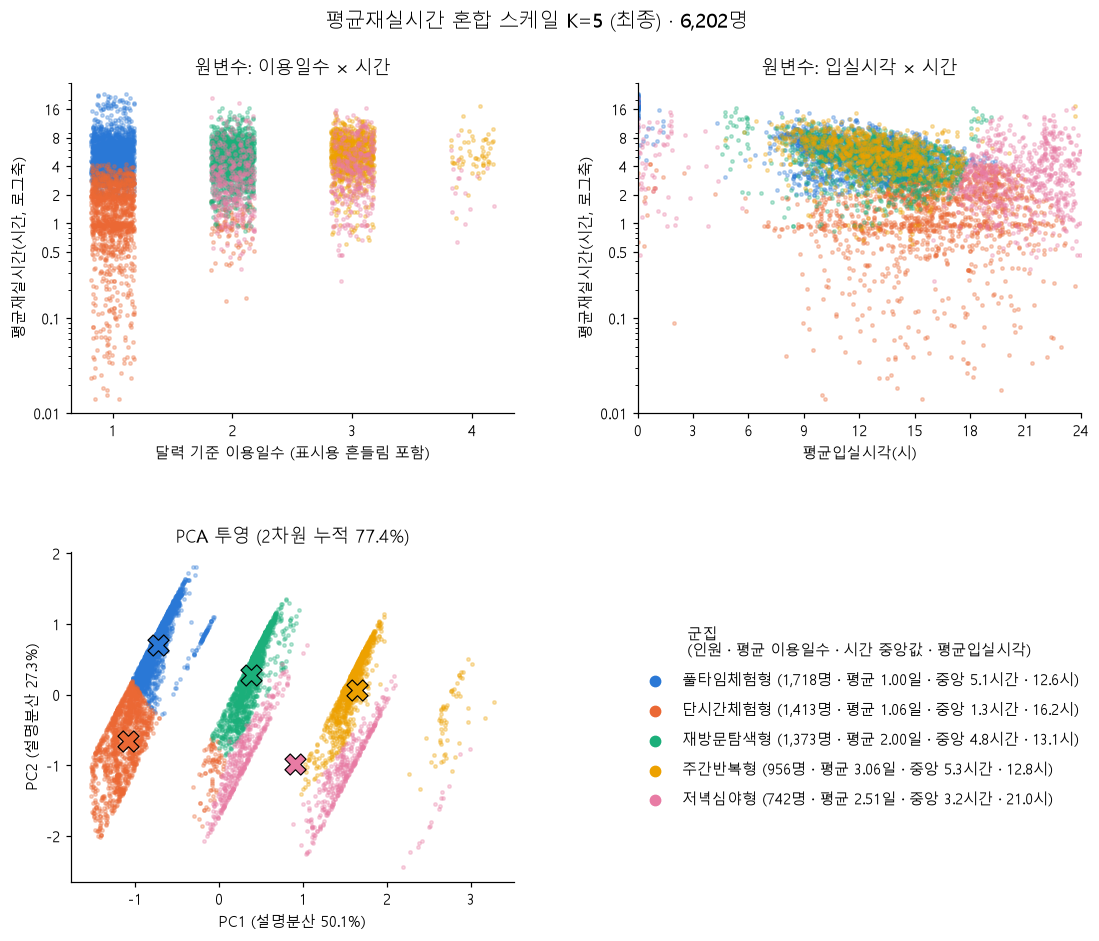

,PC1 설명분산(%),PC2 설명분산(%),2차원 누적(%),군집 인원
모델,,,,
이용구간 표준화 K=4,41.9000,28.8000,70.7000,"[2072, 1599, 1351, 1180]"
평균재실시간 표준화 K=4,43.4000,29.9000,73.3000,"[1893, 1653, 1631, 1025]"
평균재실시간 혼합 스케일 K=5 (최종),50.1000,27.3000,77.4000,"[1718, 1413, 1373, 956, 742]"


In [27]:
def unit_coords(frame, sin_col, cos_col):
    coords = frame[[sin_col, cos_col]].to_numpy(float)
    return coords / np.linalg.norm(coords, axis=1, keepdims=True)


def vector_to_hour(coords):
    return np.mod(np.arctan2(coords[..., 0], coords[..., 1]), 2 * np.pi) * 24 / (2 * np.pi)


daily_coords = unit_coords(customers, "daily_start_sin", "daily_start_cos")
variant_coords = unit_coords(variant_frame, "midnight_adjusted_enter_sin", "midnight_adjusted_enter_cos")
presence_h = customers["avg_daily_presence_h"].to_numpy(float)
SCATTER_SPECS = [
    {"모델": "이용구간 표준화 K=4", "X": X_variant, "days": variant_frame["visit_days"].to_numpy(float),
     "duration": np.expm1(variant_frame["avg_daily_stay"].to_numpy(float)), "coords": variant_coords,
     "duration_label": "일평균 이용구간(시간, 외출 포함, 로그축)", "hour_label": "자정 보정 입실시각(시)"},
    {"모델": "평균재실시간 표준화 K=4", "X": X_candidate1, "days": customers["usage_day_count"].to_numpy(float),
     "duration": presence_h, "coords": daily_coords,
     "duration_label": "평균재실시간(시간, 로그축)", "hour_label": "평균입실시각(시)"},
    {"모델": "평균재실시간 혼합 스케일 K=5 (최종)", "X": X_final, "days": customers["usage_day_count"].to_numpy(float),
     "duration": presence_h, "coords": daily_coords,
     "duration_label": "평균재실시간(시간, 로그축)", "hour_label": "평균입실시각(시)"},
]
GENERIC_COLORS = [CLUSTER_COLORS[name] for name in NAME_ORDER[:4]]   # 후보 모델의 군집 1~4 구분용
DURATION_TICKS = [0.01, 0.1, 0.5, 1, 2, 4, 8, 16]


def cluster_order(spec, model_label):
    counts = np.bincount(model_label)
    if spec["모델"].endswith("(최종)"):
        name_to_id = {name: cid for cid, name in CLUSTER_NAMES.items()}
        items = [(name_to_id[name], name, CLUSTER_COLORS[name]) for name in NAME_ORDER]
    else:
        ids = sorted(range(len(counts)), key=lambda c: -counts[c])
        items = [(cid, f"군집 {rank + 1}", GENERIC_COLORS[rank]) for rank, cid in enumerate(ids)]
    result = []
    for cid, name, color in items:
        m = model_label == cid
        hour = float(vector_to_hour(spec["coords"][m].mean(axis=0)))
        label = (f"{name} ({m.sum():,}명 · 평균 {spec['days'][m].mean():.2f}일 · "
                 f"중앙 {np.median(spec['duration'][m]):.1f}시간 · {hour:.1f}시)")
        result.append((cid, color, label))
    return result


day_jitter = np.random.default_rng(SEED).uniform(-0.18, 0.18, len(customers))   # 표시용, 세 모델 공통
pca_rows = []
for spec in SCATTER_SPECS:
    model_label = model_labels[spec["모델"]]
    assert len(model_label) == len(spec["X"]) == len(customers) == 6202
    hours = vector_to_hour(spec["coords"])
    pca_model = PCA(n_components=2, random_state=SEED).fit(spec["X"])
    pc = pca_model.transform(spec["X"])
    ratio = pca_model.explained_variance_ratio_ * 100
    order = cluster_order(spec, model_label)

    fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.8))
    fig.subplots_adjust(left=0.085, right=0.985, top=0.90, bottom=0.075, wspace=0.28, hspace=0.42)
    axes = axes.ravel()
    for cid, color, label in order:
        m = model_label == cid
        axes[0].scatter(spec["days"][m] + day_jitter[m], spec["duration"][m], s=5, alpha=0.3, color=color, label=label)
        axes[1].scatter(hours[m], spec["duration"][m], s=5, alpha=0.3, color=color)
        axes[2].scatter(pc[m, 0], pc[m, 1], s=5, alpha=0.3, color=color)
        axes[2].scatter(*pc[m].mean(axis=0), s=190, marker="X", color=color, edgecolor="black", linewidth=0.8)
    for ax in axes[:2]:
        ax.set_yscale("log")
        ax.set_ylim(0.01, 30)
        ax.set_yticks(DURATION_TICKS)
        ax.set_yticklabels([f"{t:g}" for t in DURATION_TICKS])
        ax.set_ylabel(spec["duration_label"])
    axes[0].set_xticks([1, 2, 3, 4])
    axes[0].set_xlabel("달력 기준 이용일수 (표시용 흔들림 포함)")
    axes[0].set_title("원변수: 이용일수 × 시간", fontsize=12)
    axes[1].set_xlim(0, 24)
    axes[1].set_xticks(range(0, 25, 3))
    axes[1].set_xlabel(spec["hour_label"])
    axes[1].set_title("원변수: 입실시각 × 시간", fontsize=12)
    axes[2].set_xlabel(f"PC1 (설명분산 {ratio[0]:.1f}%)")
    axes[2].set_ylabel(f"PC2 (설명분산 {ratio[1]:.1f}%)")
    axes[2].set_title(f"PCA 투영 (2차원 누적 {ratio.sum():.1f}%)", fontsize=12)
    for ax in axes[:3]:
        ax.spines[["top", "right"]].set_visible(False)
    axes[3].axis("off")
    handles, texts = axes[0].get_legend_handles_labels()
    legend = axes[3].legend(handles, texts, loc="center", frameon=False, fontsize=10, markerscale=3,
                            labelspacing=0.9, borderaxespad=0.2,
                            title="군집" + chr(10) + "(인원 · 평균 이용일수 · 시간 중앙값 · 평균입실시각)", title_fontsize=10)
    for handle in legend.legend_handles:
        handle.set_alpha(1)
    fig.suptitle(f"{spec['모델']} · {len(customers):,}명", fontsize=13, y=0.975)
    plt.show()
    pca_rows.append({"모델": spec["모델"], "PC1 설명분산(%)": ratio[0], "PC2 설명분산(%)": ratio[1],
                     "2차원 누적(%)": ratio.sum(), "군집 인원": sorted(np.bincount(model_label).tolist(), reverse=True)})

display(pd.DataFrame(pca_rows).set_index("모델").round(1))

- **이용구간 표준화 K=4:** 입실시각 × 시간 그림에서 군집이 주로 입실시각 구간(오전 10시 전후, 오후 2~3시, 저녁 8시 전후)을 따라 나뉘는 모습이 관측된다. 1일 이용 고객은 세 군집에 섞여 있고, 여러 날 이용 고객은 군집 2(평균 2.77일)에 모인다.
- **평균재실시간 표준화 K=4:** 1일 이용 고객은 평균재실시간에 따라 군집 2(짧음)와 군집 3(김)으로 나뉜다. 2일 이상 이용 고객은 입실시각에 따라 군집 1(낮)과 군집 4(저녁)로 나뉘며, 2일과 3일 이상 이용 고객이 같은 군집에 섞인다.
- **평균재실시간 혼합 스케일 K=5 (최종):** 1일 이용 고객은 평균재실시간에 따라 풀타임체험형과 단시간체험형으로 나뉜다. 여러 날 이용 고객은 달력 이용일수에 따라 재방문탐색형(2일)과 주간반복형(평균 3.06일)으로 나뉘고, 늦은 시간에 입실한 고객은 이용일수와 관계없이 저녁심야형으로 모인다.
- 평균재실시간 두 모델의 PCA 그림에 보이는 평행한 띠는 이용일수가 1~4의 정수여서 생긴다. 최종 모델은 띠가 이용일수별로 더 뚜렷하게 떨어져 있다.
- 2차원 PCA의 누적 설명분산은 70.7~77.4%로 정보 일부가 투영에서 빠진다. 따라서 산점도는 6절 지표로 선정한 결과를 시각적으로 확인하는 보조 자료로 사용하며, 그림의 겉보기 분리만으로 모델을 고르지 않는다.

## 8. 최종 군집 프로파일

평균값 하나로 군집을 설명하지 않도록 중앙값과 사분위 범위를 함께 제시한다. 평균입실시각은 군집 안 고객들의 평균입실시각을 다시 원형평균한 값이다.

In [28]:
grouped = customers.groupby("군집", observed=True)
profile = pd.DataFrame({
    "인원": grouped.size(),
    "비중(%)": grouped.size() / len(customers) * 100,
    "이용일수 평균": grouped["usage_day_count"].mean(),
    "이용일수 중앙값": grouped["usage_day_count"].median(),
    "평균재실시간 평균(시간)": grouped["avg_daily_presence_h"].mean(),
    "평균재실시간 중앙값(시간)": grouped["avg_daily_presence_h"].median(),
    "평균재실시간 Q1": grouped["avg_daily_presence_h"].quantile(0.25),
    "평균재실시간 Q3": grouped["avg_daily_presence_h"].quantile(0.75),
    "평균입실시각(시)": pd.Series({name: circular_mean_hour(customers[customers["군집"].eq(name)]) for name in NAME_ORDER}),
    "관측 결제율(%)": grouped["is_payment"].mean() * 100,
}).reindex(NAME_ORDER)
display(profile.round(2))

posthoc = pd.DataFrame({
    "이용회차 평균": grouped["episode_count_strict"].mean(),
    "이용회차당 재실시간 중앙값(시간)": grouped["avg_episode_presence_h_strict"].median(),
    "자정연결인원": grouped["exact_midnight_links"].apply(lambda s: int(s.gt(0).sum())),
    "주말 이용 비율 평균(%)": grouped["weekend_usage_ratio"].mean() * 100,
    "비재실 비율 평균(%)": grouped["daily_outside_ratio"].mean() * 100,
    "비재실 비율 중앙값(%)": grouped["daily_outside_ratio"].median() * 100,
    "리드타임 평균(일)": grouped["lead_time_days"].mean(),
    "미결제 인원": grouped["is_payment"].apply(lambda s: int((s == 0).sum())),
}).reindex(NAME_ORDER)
posthoc["미결제 비율(%)"] = posthoc["미결제 인원"] / profile["인원"] * 100

consistency = pd.DataFrame({
    "입실시각 일관성 평균": grouped["daily_start_vector_strength"].mean(),
    "입실시각 일관성 중앙값": grouped["daily_start_vector_strength"].median(),
    "0.5 미만 인원": grouped["daily_start_vector_strength"].apply(lambda s: int(s.lt(0.5).sum())),
    "0.5 미만 비율(%)": grouped["daily_start_vector_strength"].apply(lambda s: s.lt(0.5).mean() * 100),
    "0.8 이상 비율(%)": grouped["daily_start_vector_strength"].apply(lambda s: s.ge(0.8).mean() * 100),
}).reindex(NAME_ORDER)
print("사후 비교 변수 (군집 생성에 사용하지 않음)")
display(posthoc.round(2))
print("입실시각 일관성(0~1): 여러 이용일에 비슷한 시각에 입실할수록 1에 가깝다. 1일 이용 고객은 정의상 1이다.")
display(consistency.round(3))

,인원,비중(%),이용일수 평균,이용일수 중앙값,평균재실시간 평균(시간),평균재실시간 중앙값(시간),평균재실시간 Q1,평균재실시간 Q3,평균입실시각(시),관측 결제율(%)
풀타임체험형,1718,27.7000,1.0000,1.0000,5.7700,5.1200,3.7900,6.8800,12.5700,29.5700
단시간체험형,1413,22.7800,1.0600,1.0000,1.4900,1.3000,0.8500,2.0900,16.1900,38.1500
재방문탐색형,1373,22.1400,2.0000,2.0000,5.1100,4.7700,3.4300,6.4900,13.0600,39.3300
주간반복형,956,15.4100,3.0600,3.0000,5.6900,5.3500,4.0900,7.2100,12.8100,45.9200
저녁심야형,742,11.9600,2.5100,2.0000,4.0000,3.2200,1.9200,5.1900,21.0100,49.6000


사후 비교 변수 (군집 생성에 사용하지 않음)


,이용회차 평균,이용회차당 재실시간 중앙값(시간),자정연결인원,주말 이용 비율 평균(%),비재실 비율 평균(%),비재실 비율 중앙값(%),리드타임 평균(일),미결제 인원,미결제 비율(%)
군집,,,,,,,,,
풀타임체험형,1.0100,5.0600,0,20.1400,9.7200,4.6900,1.2600,1210,70.4300
단시간체험형,1.0700,1.2800,0,23.0700,4.9000,0.1500,1.3500,874,61.8500
재방문탐색형,2.0000,4.7500,20,23.5600,11.0700,7.4500,0.9600,833,60.6700
주간반복형,2.9900,5.4500,88,20.0100,15.9000,11.3900,0.6900,517,54.0800
저녁심야형,1.8700,4.1300,408,26.4200,24.5000,8.6700,0.8500,374,50.4000


입실시각 일관성(0~1): 여러 이용일에 비슷한 시각에 입실할수록 1에 가깝다. 1일 이용 고객은 정의상 1이다.


,입실시각 일관성 평균,입실시각 일관성 중앙값,0.5 미만 인원,0.5 미만 비율(%),0.8 이상 비율(%)
군집,,,,,
풀타임체험형,1.0000,1.0000,0,0.0000,100.0000
단시간체험형,0.9900,1.0000,10,0.7080,98.4430
재방문탐색형,0.8780,0.9730,101,7.3560,80.7720
주간반복형,0.8230,0.9230,129,13.4940,70.0840
저녁심야형,0.7530,0.8440,165,22.2370,57.0080


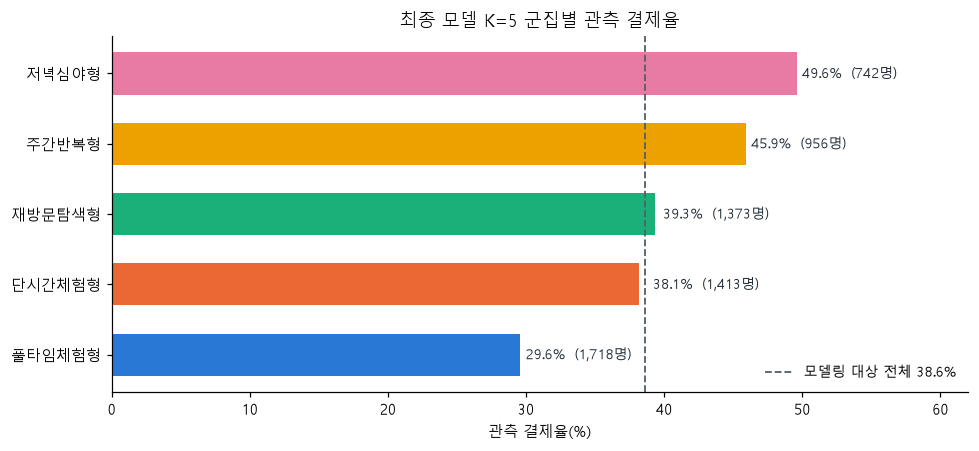

In [29]:
fig, ax = plt.subplots(figsize=(9, 4.2))
values = profile["관측 결제율(%)"]
ax.barh(NAME_ORDER, values, color=[CLUSTER_COLORS[n] for n in NAME_ORDER], height=0.6)
overall = customers["is_payment"].mean() * 100
ax.axvline(overall, color=MUTED, linestyle="--", linewidth=1.2, label=f"모델링 대상 전체 {overall:.1f}%")
ax.legend(loc="lower right", frameon=False, fontsize=9)
for i, (name, v) in enumerate(values.items()):
    # 기준선과 가까운 막대는 라벨을 기준선 오른쪽으로 옮겨 겹침을 피한다.
    label_x = max(v, overall) + 0.6 if abs(v - overall) < 1.5 else v + 0.4
    ax.text(label_x, i, f"{v:.1f}%  ({int(profile.loc[name, '인원']):,}명)", va="center", fontsize=9, color=INK,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.0), zorder=3)
ax.set_xlim(0, 62)
ax.set_xlabel("관측 결제율(%)")
ax.set_title("최종 모델 K=5 군집별 관측 결제율")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

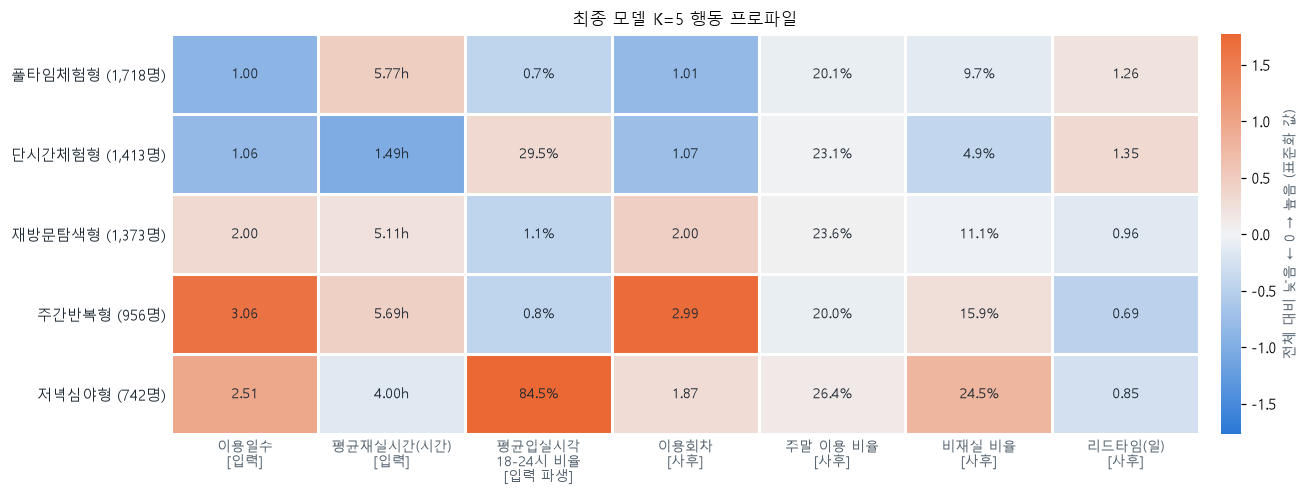

In [30]:
# 행동 프로파일 히트맵: 색은 전체 고객 대비 군집 평균의 표준화 값, 숫자는 원 단위 군집 평균
# 평균입실시각은 순환 변수이므로 시각 자체를 표준화하지 않고 '평균입실시각 18-24시 비율'로 표시한다.
heat_vars = {
    "이용일수 [입력]": customers["usage_day_count"],
    "평균재실시간(시간) [입력]": customers["avg_daily_presence_h"],
    "평균입실시각 18-24시 비율 [입력 파생]": customers["daily_start_hour"].ge(18).astype(float),
    "이용회차 [사후]": customers["episode_count_strict"],
    "주말 이용 비율 [사후]": customers["weekend_usage_ratio"],
    "비재실 비율 [사후]": customers["daily_outside_ratio"],
    "리드타임(일) [사후]": customers["lead_time_days"].astype(float),
}
z_table = pd.DataFrame({name: ((s - s.mean()) / s.std(ddof=0)).groupby(customers["군집"], observed=True).mean()
                        for name, s in heat_vars.items()}).reindex(NAME_ORDER)
raw_table = pd.DataFrame({name: s.groupby(customers["군집"], observed=True).mean()
                          for name, s in heat_vars.items()}).reindex(NAME_ORDER)


def fmt(col, v):
    if "비율" in col:
        return f"{v * 100:.1f}%"
    if "시간" in col:
        return f"{v:.2f}h"
    return f"{v:.2f}"


# x축 라벨은 폭에 맞춰 줄을 나눈다. 한 줄이 길면 옆 열 라벨과 붙어 한 문구처럼 보인다.
def wrap_label(col, width=10):
    name, tag = col.split(" [")
    lines, current = [], ""
    for token in name.split(" "):
        if current and len(current) + 1 + len(token) > width:
            lines.append(current)
            current = token
        else:
            current = f"{current} {token}".strip()
    lines.append(current)
    lines.append("[" + tag)
    return "\n".join(lines)


limit = float(np.abs(z_table.to_numpy()).max())
norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.imshow(z_table.to_numpy(), cmap=DIVERGING, norm=norm, aspect="auto")
ax.set_xticks(range(z_table.shape[1]))
ax.set_xticklabels([wrap_label(c) for c in z_table.columns], fontsize=9, color=MUTED)
ax.set_yticks(range(z_table.shape[0]))
ax.set_yticklabels([f"{n} ({int(profile.loc[n, '인원']):,}명)" for n in NAME_ORDER], fontsize=10, color=INK)
for i in range(z_table.shape[0]):
    for j, col in enumerate(z_table.columns):
        ax.text(j, i, fmt(col, raw_table.iloc[i, j]), ha="center", va="center", fontsize=9, color=INK)
ax.set_xticks(np.arange(-0.5, z_table.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, z_table.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.tick_params(which="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
bar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=DIVERGING), ax=ax, fraction=0.025, pad=0.02)
bar.set_label("전체 대비 낮음 ← 0 → 높음 (표준화 값)", fontsize=9, color=MUTED)
bar.outline.set_visible(False)
ax.set_title("최종 모델 K=5 행동 프로파일", fontsize=11)
plt.tight_layout()
plt.show()

**군집별 특징 (관측된 행동과 사후 결과)**

| 군집 | 행동 특징 | 관측 결제율 |
|---|---|---:|
| 풀타임체험형 | 하루만 방문해 낮 시간대에 길게 머문다. | 29.6% |
| 단시간체험형 | 대부분 하루 방문하며 오후에 짧게 머문다. | 38.1% |
| 재방문탐색형 | 달력 기준 2일, 이용회차 평균 2.00회이며 낮 시간대에 머무는 시간이 길다. | 39.3% |
| 주간반복형 | 달력 기준 평균 3.06일, 이용회차 평균 2.99회로 반복 이용이 가장 많고 낮 시간대를 중심으로 이용한다. | 45.9% |
| 저녁심야형 | 평균입실시각이 21시 전후이며 자정을 넘겨 이어진 이용 기록이 많다. | 49.6% |

- 주간반복형과 저녁심야형에서 관측 결제율이 각각 45.9%, 49.6%로 높았다.
- 하루만 길게 이용한 풀타임체험형의 관측 결제율이 가장 낮다. 머문 시간이 길다는 것만으로 결제율이 높게 나타나지는 않았다.
- 저녁심야형은 비재실 비율 평균이 24.5%로 가장 높지만 중앙값은 8.7%다. 비재실 비율이 일부 고객에서 크게 나타나는 오른쪽으로 치우친 분포다.
- 리드타임은 이용 가능 기간 때문에 늦게 방문한 고객이 여러 날 이용하기 어렵다는 구조적 제약이 있어, 군집의 핵심 특성이 아니라 보조적인 맥락으로만 본다.
- 결제율은 군집이 확정된 뒤 비교한 사후 결과이며, 특정 행동이 결제를 일으킨다는 뜻이 아니다.

## 9. 추가 보조 검증

이 절의 분석은 최종 모델을 고르는 근거가 아니다. 선정된 모델의 해석이 입력 설계와 자정 분할 기록에 크게 좌우되지 않는지 확인하는 보조 검증이다.

### 9.1 입실시각 일관성 R 반영 실험

평균입실시각의 평균벡터 길이 R(원형 통계의 평균 합성벡터 길이)은 입실시각이 얼마나 일정한지를 나타낸다(0~1). 최종 모델은 단위벡터로 방향만 쓰는데, R을 반영해도 군집이 유지되는지 확인한다.

- **평균벡터:** 단위벡터화 없이 평균벡터를 그대로 사용한다. 원자료 공간에서는 R × 단위벡터와 같다.
- **sample_weight=R:** 고객 전체의 영향력을 R만큼 낮춘다. 시간 외 변수의 영향력까지 함께 낮아지므로 최종 방식으로 채택하지 않는다.

In [31]:
def matched_agreement(a, b):
    table = pd.crosstab(pd.Series(a), pd.Series(b)).to_numpy()
    r, c = linear_sum_assignment(-table)
    return table[r, c].sum() / len(a)


strength = customers["daily_start_vector_strength"].to_numpy()
X_mean_vector = final_input(customers, use_mean_vector=True)
labels_mean = KMeans(K_FINAL, n_init=N_INIT, random_state=SEED).fit_predict(X_mean_vector)
labels_weight = KMeans(K_FINAL, n_init=N_INIT, random_state=SEED).fit(X_final, sample_weight=strength).predict(X_final)
r_sensitivity = pd.DataFrame([
    {"방식": "기준(단위벡터)", "기준과 ARI": 1.0, "일치율": 1.0, "silhouette": silhouette_score(X_final, labels)},
    {"방식": "평균벡터(R 반영)", "기준과 ARI": adjusted_rand_score(labels, labels_mean),
     "일치율": matched_agreement(labels, labels_mean), "silhouette": silhouette_score(X_mean_vector, labels_mean)},
    {"방식": "sample_weight=R", "기준과 ARI": adjusted_rand_score(labels, labels_weight),
     "일치율": matched_agreement(labels, labels_weight), "silhouette": silhouette_score(X_final, labels_weight)},
]).set_index("방식")
display(r_sensitivity.round(4))
print(f"R 분포: 평균 {strength.mean():.3f} · 중앙값 {np.median(strength):.3f} · 1일 이용 고객은 정의상 R=1")

,기준과 ARI,일치율,silhouette
방식,,,
기준(단위벡터),1.0000,1.0000,0.3528
평균벡터(R 반영),0.8176,0.8896,0.3286
sample_weight=R,0.9711,0.9877,0.3517


R 분포: 평균 0.914 · 중앙값 1.000 · 1일 이용 고객은 정의상 R=1


R을 반영한 평균벡터 방식과 sample-weight 방식은 기준 모델과 각각 89.0%, 98.8% 일치했지만 silhouette은 0.329와 0.352로 기준 0.353을 개선하지 못했다. 1일 이용 고객은 비교할 날이 없어 정의상 R=1이므로 R이 제공하는 추가 정보도 제한적이다. 따라서 R은 모델 입력 가중치가 아니라 사후 일관성 지표로 사용한다.

### 9.2 저녁심야형의 자정 연결 검증

저녁심야형은 자정을 넘겨 이어진 기록이 많다. 날짜 경계로 분할된 기록(23:59:59 퇴실 → 00:00:00 입실)은 새로운 입실이 아니므로, 이를 구분해 시간대 해석이 유지되는지 확인한다.

In [32]:
cohort_daily["군집"] = cohort_daily["user_uuid"].map(customers["군집"])
three_hour = [(h, h + 3) for h in range(0, 24, 3)]
labels_3h = [f"{a:02d}-{b:02d}" for a, b in three_hour]
cohort_daily["시작 구간"] = pd.cut(cohort_daily["enter_hour"], np.arange(0, 25, 3), right=False, labels=labels_3h)
customers["대표 3시간 구간"] = pd.cut(customers["daily_start_hour"], np.arange(0, 25, 3), right=False, labels=labels_3h)

night = cohort_daily[cohort_daily["군집"].eq("저녁심야형")]
links = int(night["exact_midnight_link"].sum())
rep_share = customers.loc[customers["군집"].eq("저녁심야형"), "대표 3시간 구간"].value_counts(normalize=True).reindex(labels_3h) * 100
no_link_share = night.loc[~night["exact_midnight_link"], "시작 구간"].value_counts(normalize=True).reindex(labels_3h) * 100
compare = pd.DataFrame({"평균입실시각 구간 고객 비율(%)": rep_share,
                        "자정 연속 기록 제외 고객-일 시작 비율(%)": no_link_share}).round(1)
display(compare)
evening_rep = rep_share[["18-21", "21-24"]].sum()
evening_obs = no_link_share[["18-21", "21-24"]].sum()
print(f"저녁심야형 고객-일 {len(night):,}건 중 정확 자정 연속 기록 {links:,}건({links / len(night) * 100:.1f}%)")
print(f"18-24시: 평균입실시각 기준 {evening_rep:.1f}% · 자정 연속 기록 제외 시작 기준 {evening_obs:.1f}%")
assert len(night) == 1866 and links == 493
assert abs(evening_rep - 84.5) < 0.05 and abs(evening_obs - 59.1) < 0.05

# 1시간 단위 최빈 시각: 기록상 vs 자정 연속 기록 제외
night_hour = night["enter_hour"].astype(int)
recorded_hour = night_hour.value_counts(normalize=True) * 100
no_link_hour = night_hour[~night["exact_midnight_link"]].value_counts(normalize=True) * 100
late = lambda h: h.ge(17) | h.lt(2)
hourly = pd.DataFrame([
    {"기준": "기록상 고객-일 시작", "최빈 1시간": f"{recorded_hour.idxmax():02d}-{recorded_hour.idxmax() + 1:02d}시",
     "비율(%)": recorded_hour.max(), "17~02시 비율(%)": late(night_hour).mean() * 100},
    {"기준": "자정 연속 기록 제외", "최빈 1시간": f"{no_link_hour.idxmax():02d}-{no_link_hour.idxmax() + 1:02d}시",
     "비율(%)": no_link_hour.max(), "17~02시 비율(%)": late(night_hour[~night["exact_midnight_link"]]).mean() * 100},
]).set_index("기준")
display(hourly.round(1))

,평균입실시각 구간 고객 비율(%),자정 연속 기록 제외 고객-일 시작 비율(%)
00-03,8.1000,9.9000
03-06,0.8000,0.9000
06-09,0.0000,1.1000
09-12,0.0000,3.6000
12-15,0.0000,8.4000
15-18,6.6000,17.0000
18-21,42.3000,41.2000
21-24,42.2000,17.9000


저녁심야형 고객-일 1,866건 중 정확 자정 연속 기록 493건(26.4%)
18-24시: 평균입실시각 기준 84.5% · 자정 연속 기록 제외 시작 기준 59.1%


,최빈 1시간,비율(%),17~02시 비율(%)
기준,,,
기록상 고객-일 시작,00-01시,32.5000,81.8000
자정 연속 기록 제외,19-20시,15.5000,75.3000


- 저녁심야형 고객-일 1,866건 가운데 493건(26.4%)은 전날에서 자정을 넘겨 이어진 기록이다. 기록상 최빈 시각이 00–01시로 나타나는 것은 상당 부분 이 분할 기록의 영향을 받으며, 연속 기록을 제외하면 최빈 시각은 19–20시다.
- 평균입실시각 기준 18–24시 비율 84.5%는 **평균입실시각 구간에 속한 고객의 비율**이며 실제 입실 건수의 비율이 아니다.
- 자정 연속 기록을 제외한 날짜별 최초 입실 기준으로도 18–24시가 합계 59.1%를 차지한다. 저녁 중심의 해석은 유지된다.
- 날짜별 최초 입실 분포는 같은 날 여러 번 들어온 경우를 모두 담지 않으므로 모든 입실의 분포와 같지 않다.
- 상세한 R 진단과 전체 군집의 3시간 구간 비교는 부록에 둔다.

### 9.3 재현성 점검

아래 셀은 결과를 출력하지 않고, 표본·군집 합계와 주요 지표가 분석 과정에서 바뀌지 않았는지만 확인한다.

In [33]:
# 표본과 군집 합계
assert len(customers) == 6202 and int(customers["is_payment"].sum()) == 2394
assert customers["군집"].value_counts().sum() == len(customers)
assert customers["군집"].value_counts().to_dict() == {"풀타임체험형": 1718, "단시간체험형": 1413, "재방문탐색형": 1373,
                                                  "주간반복형": 956, "저녁심야형": 742}
# 비교 모델 지표(허용오차 5e-4)
_final = comparison.loc["평균재실시간 혼합 스케일 K=5 (최종)"]
_standard = comparison.loc["평균재실시간 표준화 K=4"]
for _row, _expected in [(_final, (0.3528, 1.0582, 0.9797, 0.9551)), (_standard, (0.2919, 1.2445, 0.9799, 0.9376))]:
    _actual = (_row["silhouette"], _row["DBI"], _row["bootstrap ARI 평균"], _row["bootstrap ARI 최저"])
    assert all(abs(a - e) < 5e-4 for a, e in zip(_actual, _expected))
assert abs(_final["CH"] - 3145.70) < 0.05 and abs(_standard["CH"] - 2532.12) < 0.05
assert sorted(np.bincount(model_labels["평균재실시간 표준화 K=4"]).tolist(), reverse=True) == [1893, 1653, 1631, 1025]
# 군집 결제율(소수 첫째 자리)
_rates = (customers.groupby("군집", observed=True)["is_payment"].mean() * 100).round(1).to_dict()
assert _rates == {"풀타임체험형": 29.6, "단시간체험형": 38.1, "재방문탐색형": 39.3, "주간반복형": 45.9, "저녁심야형": 49.6}

## 10. 결론과 한계

**주요 발견**

1. 입·퇴실 시각이 모든 이용일에서 관측된 모델링 대상 6,202명은 이용일수, 평균재실시간, 평균입실시각의 세 행동축에 따라 다섯 유형(풀타임체험형, 단시간체험형, 재방문탐색형, 주간반복형, 저녁심야형)으로 구분됐다.
2. 최종 모델(평균재실시간 혼합 스케일 K=5)은 주 지표인 silhouette이 0.353으로 비교한 세 모델 중 가장 높았다. 추가 보조 검증인 bootstrap ARI도 평균 0.980·최저 0.955로 안정적으로 나타났다.
3. 관측 결제율은 주간반복형(45.9%)과 저녁심야형(49.6%)에서 높았고, 하루만 길게 머문 풀타임체험형(29.6%)에서 가장 낮았다.
4. 장시간 체류가 항상 높은 관측 결제율과 함께 나타나지는 않았으며, 달력 기준 이용일수와 이용 시간대가 다른 유형에서 관측 결제율 차이가 함께 나타났다.

**실행 가설 (검증이 필요한 제안)**

- 반복 방문 고객과 저녁 시간대 고객을 대상으로 체험 종료 전 이용권 안내를 실험해 볼 수 있다.
- 하루만 길게 이용한 고객에게는 재방문을 유도하는 안내를 실험하고, 미재방문 사유를 조사할 수 있다.
- 위 제안은 관측 결과에서 도출한 가설이며, 효과는 A/B 테스트 등으로 별도 검증해야 한다.

**한계**

- 관측자료 분석이므로 군집과 결제율 사이의 인과관계를 주장할 수 없다.
- 평균입실시각은 고객별 원형평균이어서 여러 날의 입실시각이 크게 다른 고객은 실제로 입실하지 않은 시각이 대표값이 될 수 있다. 입실시각 일관성 R을 함께 확인해야 한다.
- 달력 이용일수는 자정을 넘긴 한 번의 이용을 이틀로 셀 수 있다. 저녁심야형 해석에는 자정 연속 기록 구분 결과를 함께 제시한다.
- 방문 기록이 없는 고객 3,090명은 핵심 행동 변수를 만들 수 없어 제외했고, 방문 고객 중 입·퇴실 시각이 일부라도 결측인 332명도 모델링 대상에서 제외했다. 결과는 모델링 대상 6,202명에 한정된다.

## 부록

### A. 전체 군집의 3시간 구간 최빈 구간 비교

In [34]:
appendix_rows = []
no_link_all = cohort_daily[~cohort_daily["exact_midnight_link"]]
for name in NAME_ORDER:
    rep = customers.loc[customers["군집"].eq(name), "대표 3시간 구간"].value_counts(normalize=True)
    obs = no_link_all.loc[no_link_all["군집"].eq(name), "시작 구간"].value_counts(normalize=True)
    appendix_rows.append({"군집": name,
                          "고객-일": int(cohort_daily["군집"].eq(name).sum()),
                          "정확 자정 연속 기록": int(cohort_daily.loc[cohort_daily["군집"].eq(name), "exact_midnight_link"].sum()),
                          "평균입실시각 최빈 구간": rep.idxmax(), "비율(%)": round(rep.max() * 100, 1),
                          "연속 기록 제외 최빈 구간": obs.idxmax(), "비율(%) ": round(obs.max() * 100, 1),
                          "일치": rep.idxmax() == obs.idxmax()})
display(pd.DataFrame(appendix_rows).set_index("군집"))

,고객-일,정확 자정 연속 기록,평균입실시각 최빈 구간,비율(%),연속 기록 제외 최빈 구간,비율(%),일치
군집,,,,,,,
풀타임체험형,1718,0,12-15,44.7000,12-15,44.7000,True
단시간체험형,1497,0,15-18,34.0000,15-18,32.8000,True
재방문탐색형,2746,20,12-15,43.2000,12-15,38.3000,True
주간반복형,2926,90,12-15,41.9000,12-15,37.0000,True
저녁심야형,1866,493,18-21,42.3000,18-21,41.2000,True


### B. 저녁심야형의 입실시각 일관성 R (자정 연결 유무별)

In [35]:
night_customers = customers[customers["군집"].eq("저녁심야형")].copy()
night_customers["episode_R"] = night_customers["episode_start_vector_strength_strict"]
has_link = night_customers["exact_midnight_links"].gt(0)
r_table = pd.DataFrame([
    {"구분": label, "인원": len(sub),
     "일 기준 R 평균": sub["daily_start_vector_strength"].mean(), "일 기준 R 중앙값": sub["daily_start_vector_strength"].median(),
     "이용회차 R 평균": sub["episode_R"].mean(), "이용회차 R 중앙값": sub["episode_R"].median()}
    for label, sub in [("자정 연결 없음", night_customers[~has_link]), ("자정 연결 있음", night_customers[has_link])]
]).set_index("구분")
display(r_table.round(3))
print("자정 연결 고객은 회차 연결 후 R이 높아져 날짜 경계 분할의 영향이 포함됐음을 보여준다.")
print("다만 연결 후 한 회차만 남은 고객은 정의상 R=1이므로, 회차 기준 R은 보조 근거로 해석한다.")

,인원,일 기준 R 평균,일 기준 R 중앙값,이용회차 R 평균,이용회차 R 중앙값
구분,,,,,
자정 연결 없음,334,0.8480,0.9500,0.8450,0.9430
자정 연결 있음,408,0.6760,0.7250,0.8510,1.0000


자정 연결 고객은 회차 연결 후 R이 높아져 날짜 경계 분할의 영향이 포함됐음을 보여준다.
다만 연결 후 한 회차만 남은 고객은 정의상 R=1이므로, 회차 기준 R은 보조 근거로 해석한다.


### C. 평균재실시간 표준화 K=4 군집 프로파일 (6,202명)

In [36]:
c1_labels = model_labels["평균재실시간 표준화 K=4"]
c1_profile = pd.DataFrame({
    "인원": pd.Series(c1_labels).value_counts().sort_index(),
    "이용일수 평균": customers.groupby(c1_labels)["usage_day_count"].mean(),
    "평균재실시간 중앙값(시간)": customers.groupby(c1_labels)["avg_daily_presence_h"].median(),
    "평균입실시각(시)": pd.Series({c: circular_mean_hour(customers[c1_labels == c]) for c in range(4)}),
    "관측 결제율(%)": customers.groupby(c1_labels)["is_payment"].mean() * 100,
}).sort_values("평균입실시각(시)")
display(c1_profile.round(2))
print(f"평균재실시간 표준화 K=4와 최종 모델의 ARI: {adjusted_rand_score(c1_labels, labels):.3f}")

,인원,이용일수 평균,평균재실시간 중앙값(시간),평균입실시각(시),관측 결제율(%)
0,1893,2.4500,5.4600,12.2600,39.9900
2,1631,1.0000,5.2500,12.4100,28.8800
1,1653,1.1400,1.4600,15.9900,40.1700
3,1025,2.5300,3.5000,19.5600,48.9800


평균재실시간 표준화 K=4와 최종 모델의 ARI: 0.692
